In [1]:
import os

# Download do dataset caso não exista localmente (Útil para Google Colab)
csv_file = 'timeseries_seed_101.csv'
if not os.path.exists(csv_file):
    print(f"Baixando {csv_file} do GitHub...")
    !wget -q https://raw.githubusercontent.com/rafaelwilliamm/glaukopis/main/timeseries_analysis/timeseries_seed_101.csv
    print("Download concluído.")
else:
    print(f"{csv_file} já existe localmente.")

timeseries_seed_101.csv já existe localmente.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rafaelwilliamm/glaukopis/blob/main/timeseries_analysis/Cap3_Decomposicao_Series_Temporais_Radar.ipynb)

# Capítulo 3 — Decomposição de Séries Temporais
### Aplicação ao Engajamento Radar BVR (Simulador Glaukopis)

**Referência**: Hyndman, R.J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3rd ed. [otexts.com/fpp3/decomposition.html](https://otexts.com/fpp3/decomposition.html)

---

Este notebook aplica os conceitos do **Capítulo 3 do FPP3** aos dados de simulação tática do **Glaukopis**. O objetivo é decompor as séries temporais do engajamento BVR em componentes interpretáveis: **tendência-ciclo** ($T_t$), **sazonalidade** ($S_t$) e **resíduo** ($R_t$), utilizando técnicas de médias móveis, decomposição clássica e STL.

#### Modelo de Decomposição

$$y_t = T_t + S_t + R_t \quad \text{(aditivo)}$$
$$y_t = T_t \times S_t \times R_t \quad \text{(multiplicativo)}$$

#### Mapeamento Capítulo 3 → Dados Radar

| Conceito FPP3 | Variável Radar | Interpretação Física |
|---------------|----------------|----------------------|
| **Transformações (§3.1)** | `snr_db`, `TGT_01_rcs_instantaneous` | Estabilização de variância via Box-Cox/log |
| **Componente Tendência** | `TGT_01_pos_x` | Trajetória cinemática determinística (RK4) |
| **Componente Ruído** | `snr_db` | Degradação estocástica do canal de propagação |
| **Médias Móveis (§3.3)** | `snr_db`, `g_force` | Suavização para extração da tendência |
| **Decomposição (§3.4/3.6)** | `miss_distance_m` | Separação de dinâmica determinística vs. perturbações |

#### Seções Cobertas
- §3.1 Transformações e Ajustes (Box-Cox, Log)
- §3.2 Componentes de Séries Temporais
- §3.3 Médias Móveis (SMA, WMA, 2×m-MA)
- §3.4 Decomposição Clássica (Aditiva)
- §3.6 Decomposição STL

> **Nota**: A seção §3.5 (Métodos de agências oficiais — X-11, SEATS) não se aplica a este dataset, pois são específicos para séries econômicas mensais/trimestrais.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Configuração global de estilo
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Paleta de cores consistente (mesma do Cap2)
COLORS = {
    'trend': '#2ecc71',       # Verde — tendência/sinal puro
    'noise': '#9b59b6',       # Roxo — ruído/SNR
    'rcs': '#e74c3c',         # Vermelho — RCS instantâneo
    'rcs_mean': '#c0392b',    # Vermelho escuro — RCS médio
    'interceptor': '#e67e22', # Laranja — míssil
    'threshold': '#e74c3c',   # Vermelho — limiar
    'gforce': '#3498db',      # Azul — G-force
    'miss': '#1abc9c',        # Turquesa — miss distance
    'acf_bar': '#2c3e50',     # Cinza escuro — barras do ACF
    'ma': '#D55E00',          # Laranja escuro — médias móveis
    'seasonal': '#0072B2',    # Azul escuro — componente sazonal
    'remainder': '#CC79A7',   # Rosa — resíduo
    'original': '#999999',    # Cinza — dados originais (fundo)
    'transform': '#F0E442',   # Amarelo — dados transformados
}

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 0. Carregamento e Inspeção dos Dados

In [3]:
df = pd.read_csv('timeseries_seed_101.csv')

# Informações gerais
n_samples = len(df)
dt = df['time'].diff().median()
fs = 1.0 / dt

print(f"Dimensões: {n_samples} amostras × {df.shape[1]} variáveis")
print(f"Intervalo temporal: {df['time'].min()}s a {df['time'].max()}s")
print(f"Taxa de amostragem: {fs:.0f} Hz")
print(f"Resolução temporal (Δt): {dt}s")

df.head()

Dimensões: 316 amostras × 19 variáveis
Intervalo temporal: 0.0s a 31.5s
Taxa de amostragem: 10 Hz
Resolução temporal (Δt): 0.09999999999999987s


,time,random_seed,scenario_id,TGT_01_pos_x,TGT_01_pos_y,TGT_01_pos_z,INTERCEPTOR_01_pos_x,INTERCEPTOR_01_pos_y,INTERCEPTOR_01_pos_z,snr_db,miss_distance_m,g_force,track_status,missile_launched,TGT_01_rcs_instantaneous,TGT_01_rcs_mean,TGT_01_sigma_min,TGT_01_sigma_max,TGT_01_display_label
0,0.0,101,SU27_01_43km_head-on,42960.0,2005.0,3998.0,0.0,0.0,0.0,-0.73,0.0,0.0,SEARCHING,False,2.44600,3.36685,3.0,15.0,Su-27 Flanker — σ=3–15 m²
1,0.1,101,SU27_01_43km_head-on,42920.0,2010.0,3996.0,0.0,0.0,0.0,-7.25,0.0,0.0,SEARCHING,False,0.30000,3.36753,3.0,15.0,Su-27 Flanker — σ=3–15 m²
2,0.2,101,SU27_01_43km_head-on,42880.0,2015.0,3994.0,0.0,0.0,0.0,15.02,0.0,0.0,TENTATIVE,False,3.89386,3.36821,3.0,15.0,Su-27 Flanker — σ=3–15 m²
3,0.3,101,SU27_01_43km_head-on,42840.0,2020.0,3992.0,0.0,0.0,0.0,-0.93,0.0,0.0,TENTATIVE,False,0.70964,3.36889,3.0,15.0,Su-27 Flanker — σ=3–15 m²
4,0.4,101,SU27_01_43km_head-on,42800.0,2025.0,3990.0,0.0,0.0,0.0,-6.97,0.0,0.0,TENTATIVE,False,1.46262,3.36957,3.0,15.0,Su-27 Flanker — σ=3–15 m²


---
## §3.1 — Transformações e Ajustes

O FPP3 discute transformações matemáticas para **estabilizar a variância** e simplificar padrões, tornando-os mais fáceis de modelar. As principais transformações são:

- **Transformação logarítmica**: $w_t = \log(y_t)$
- **Transformação Box-Cox**: $w_t = \begin{cases} \log(y_t) & \text{se } \lambda = 0 \\ (y_t^\lambda - 1)/\lambda & \text{caso contrário} \end{cases}$

No contexto radar, o **RCS instantâneo** (`TGT_01_rcs_instantaneous`) segue o modelo de Swerling e apresenta **variância proporcional ao nível** — exatamente o cenário onde a transformação Box-Cox é mais útil.

> **Analogia Radar → FPP3**: A cintilação Swerling do RCS é análoga à variação sazonal crescente de séries econômicas — a transformação estabiliza a escala.

### 3.1.1 — Análise de Variância do RCS Instantâneo

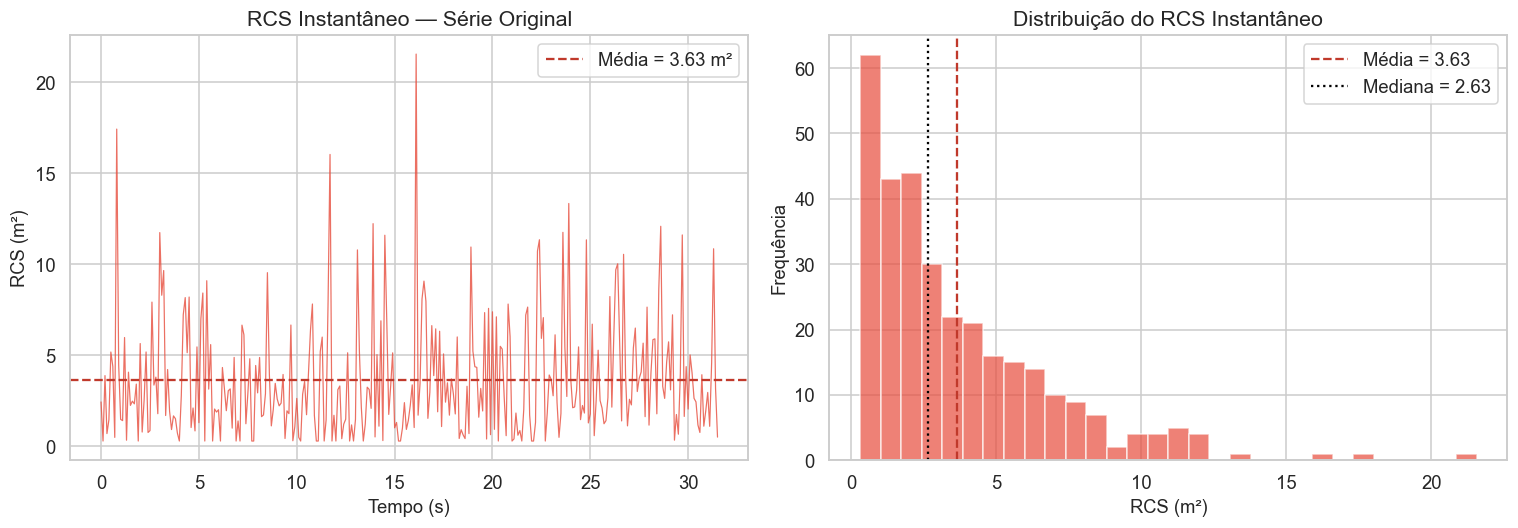

Assimetria (skewness): 1.652
Curtose (excess kurtosis): 3.831
→ Distribuição assimétrica positiva, leptocúrtica


In [4]:
rcs = df['TGT_01_rcs_instantaneous'].values
time = df['time'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Série original
axes[0].plot(time, rcs, color=COLORS['rcs'], alpha=0.8, linewidth=0.8)
axes[0].axhline(rcs.mean(), color=COLORS['rcs_mean'], linestyle='--', 
                label=f'Média = {rcs.mean():.2f} m²')
axes[0].set_xlabel('Tempo (s)')
axes[0].set_ylabel('RCS (m²)')
axes[0].set_title('RCS Instantâneo — Série Original')
axes[0].legend()

# Histograma para verificar assimetria
axes[1].hist(rcs, bins=30, color=COLORS['rcs'], alpha=0.7, edgecolor='white')
axes[1].axvline(rcs.mean(), color=COLORS['rcs_mean'], linestyle='--', 
                label=f'Média = {rcs.mean():.2f}')
axes[1].axvline(np.median(rcs), color='black', linestyle=':', 
                label=f'Mediana = {np.median(rcs):.2f}')
axes[1].set_xlabel('RCS (m²)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição do RCS Instantâneo')
axes[1].legend()

plt.tight_layout()
plt.show()

skew = stats.skew(rcs)
kurt = stats.kurtosis(rcs)
print(f"Assimetria (skewness): {skew:.3f}")
print(f"Curtose (excess kurtosis): {kurt:.3f}")
print(f"→ Distribuição {'assimétrica positiva' if skew > 0.5 else 'aproximadamente simétrica'}, "
      f"{'leptocúrtica' if kurt > 0 else 'platocúrtica'}")

### 3.1.2 — Transformação Box-Cox do RCS

Utilizamos o método de Guerrero (via `scipy.stats.boxcox`) para encontrar o $\lambda$ ótimo que estabiliza a variância.

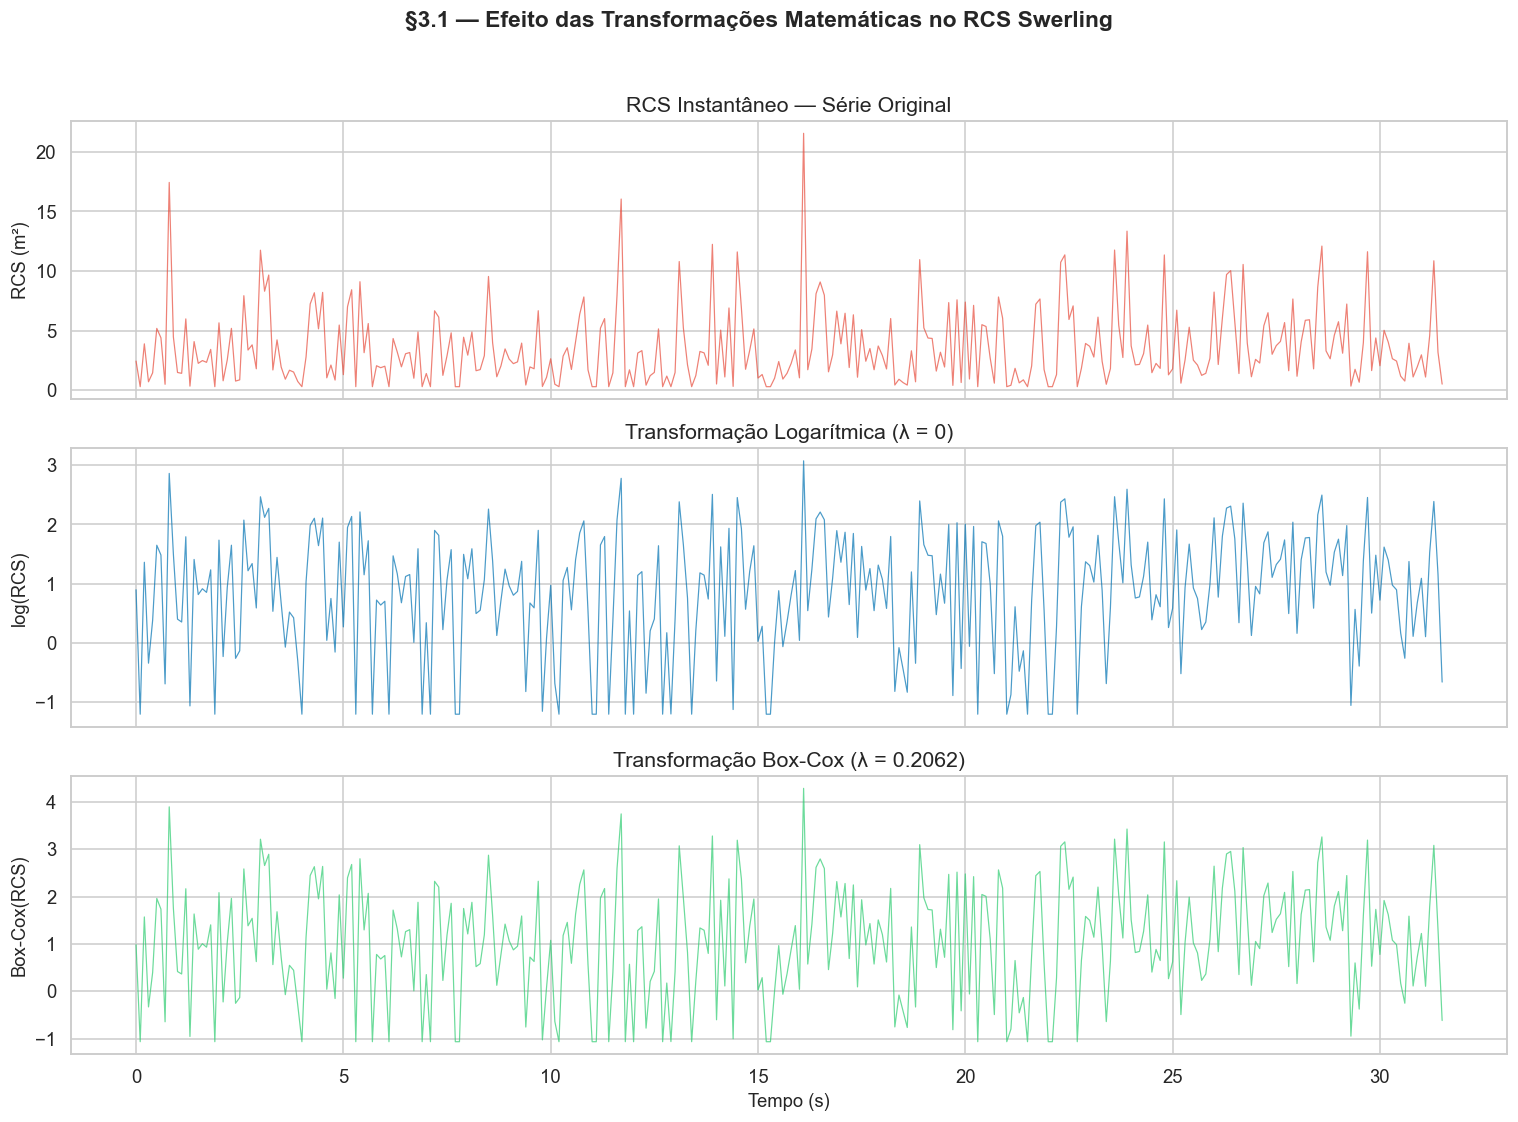


 Lambda ótimo (Box-Cox): λ = 0.2062
 Variância original: 10.6300
 Variância (log):    1.0812
 Variância (Box-Cox): 1.4570

→ A transformação Box-Cox com λ=0.2062 estabiliza a escala da cintilação Swerling.


In [5]:
# Transformação Box-Cox (requer valores estritamente positivos)
rcs_positive = rcs[rcs > 0]  # Garantir positividade
time_positive = time[rcs > 0]

rcs_boxcox, lambda_opt = stats.boxcox(rcs_positive)

# Transformação log para comparação
rcs_log = np.log(rcs_positive)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Original
axes[0].plot(time_positive, rcs_positive, color=COLORS['rcs'], alpha=0.7, linewidth=0.8)
axes[0].set_ylabel('RCS (m²)')
axes[0].set_title('RCS Instantâneo — Série Original')

# Log
axes[1].plot(time_positive, rcs_log, color=COLORS['seasonal'], alpha=0.7, linewidth=0.8)
axes[1].set_ylabel('log(RCS)')
axes[1].set_title('Transformação Logarítmica (λ = 0)')

# Box-Cox
axes[2].plot(time_positive, rcs_boxcox, color=COLORS['trend'], alpha=0.7, linewidth=0.8)
axes[2].set_ylabel(f'Box-Cox(RCS)')
axes[2].set_xlabel('Tempo (s)')
axes[2].set_title(f'Transformação Box-Cox (λ = {lambda_opt:.4f})')

plt.suptitle('§3.1 — Efeito das Transformações Matemáticas no RCS Swerling', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n Lambda ótimo (Box-Cox): λ = {lambda_opt:.4f}")
print(f" Variância original: {np.var(rcs_positive):.4f}")
print(f" Variância (log):    {np.var(rcs_log):.4f}")
print(f" Variância (Box-Cox): {np.var(rcs_boxcox):.4f}")
print(f"\n→ A transformação Box-Cox com λ={lambda_opt:.4f} estabiliza a escala da cintilação Swerling.")

### 3.1.3 — Transformação Logarítmica do SNR

O `snr_db` já está em decibéis (escala logarítmica por definição: $\text{SNR}_{\text{dB}} = 10 \log_{10}(\text{SNR}_{\text{linear}})$). Isto representa uma transformação natural que já estabiliza a variância do sinal. Verificamos que a variância é relativamente constante ao longo do tempo.

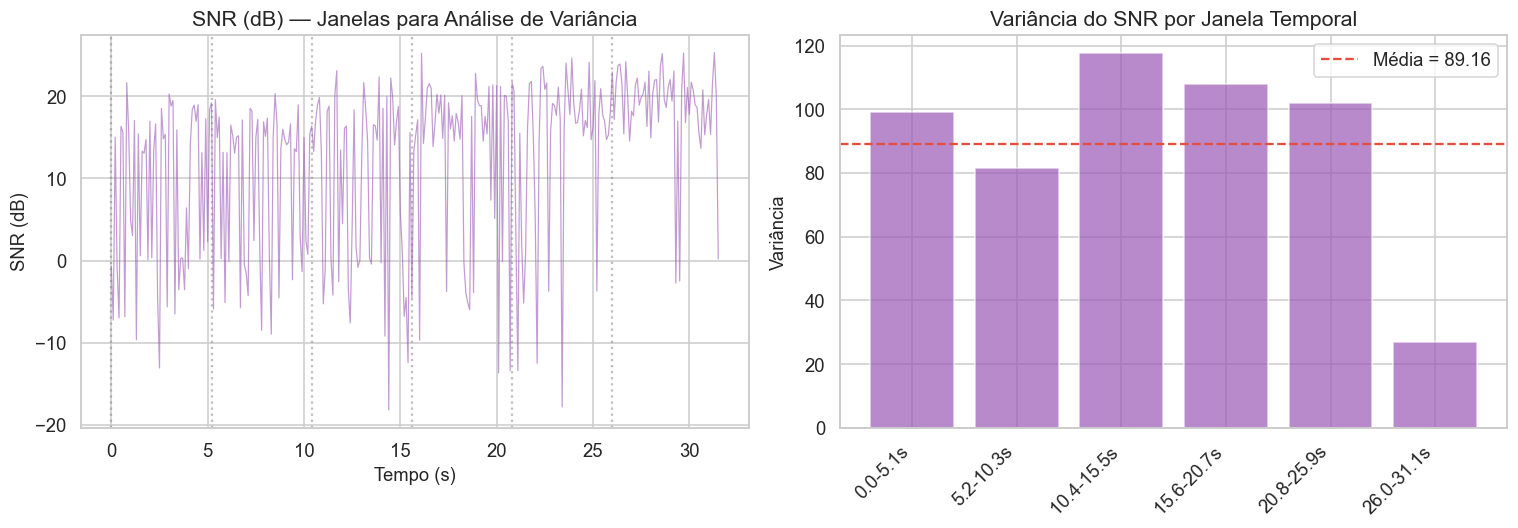

Coeficiente de variação das variâncias: 0.335
→ Variância estável: a escala dB já atua como transformação logarítmica estabilizadora.


In [6]:
snr = df['snr_db'].values

# Dividir em janelas para verificar estabilidade da variância
n_windows = 6
window_size = len(snr) // n_windows
variances = []
means = []
labels = []

for i in range(n_windows):
    start = i * window_size
    end = min(start + window_size, len(snr))
    window = snr[start:end]
    variances.append(np.var(window))
    means.append(np.mean(window))
    t_start = time[start]
    t_end = time[min(end-1, len(time)-1)]
    labels.append(f'{t_start:.1f}-{t_end:.1f}s')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Série SNR com janelas
axes[0].plot(time, snr, color=COLORS['noise'], alpha=0.6, linewidth=0.8)
for i in range(n_windows):
    start = i * window_size
    end = min(start + window_size, len(snr))
    axes[0].axvline(time[start], color='gray', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Tempo (s)')
axes[0].set_ylabel('SNR (dB)')
axes[0].set_title('SNR (dB) — Janelas para Análise de Variância')

# Variância por janela
x_pos = np.arange(len(labels))
bars = axes[1].bar(x_pos, variances, color=COLORS['noise'], alpha=0.7, edgecolor='white')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_ylabel('Variância')
axes[1].set_title('Variância do SNR por Janela Temporal')
axes[1].axhline(np.mean(variances), color=COLORS['threshold'], linestyle='--', 
                label=f'Média = {np.mean(variances):.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

cv = np.std(variances) / np.mean(variances)
print(f"Coeficiente de variação das variâncias: {cv:.3f}")
print(f"→ {'Variância estável' if cv < 0.5 else 'Variância instável'}: "
      f"a escala dB já atua como transformação logarítmica estabilizadora.")

---
## §3.2 — Componentes de Séries Temporais

O FPP3 descreve que qualquer série temporal pode ser decomposta em três componentes:

1. **Tendência-Ciclo** ($T_t$): Movimento de longo prazo da série
2. **Sazonalidade** ($S_t$): Padrões que se repetem em intervalos fixos
3. **Resíduo** ($R_t$): Variação irregular remanescente

No engajamento radar de 31.5s, não existe sazonalidade calendárica, mas podemos identificar:
- **Tendência**: Evolução cinemática (trajetória balística) 
- **Quasi-sazonalidade**: Oscilações da guiagem PN do interceptador
- **Resíduo**: Ruído térmico, cintilação RCS

> **Modelo adotado**: Decomposição aditiva ($y_t = T_t + S_t + R_t$), pois a magnitude das flutuações não é proporcional ao nível da série para as variáveis cinemáticas.

### 3.2.1 — Identificação Visual dos Componentes

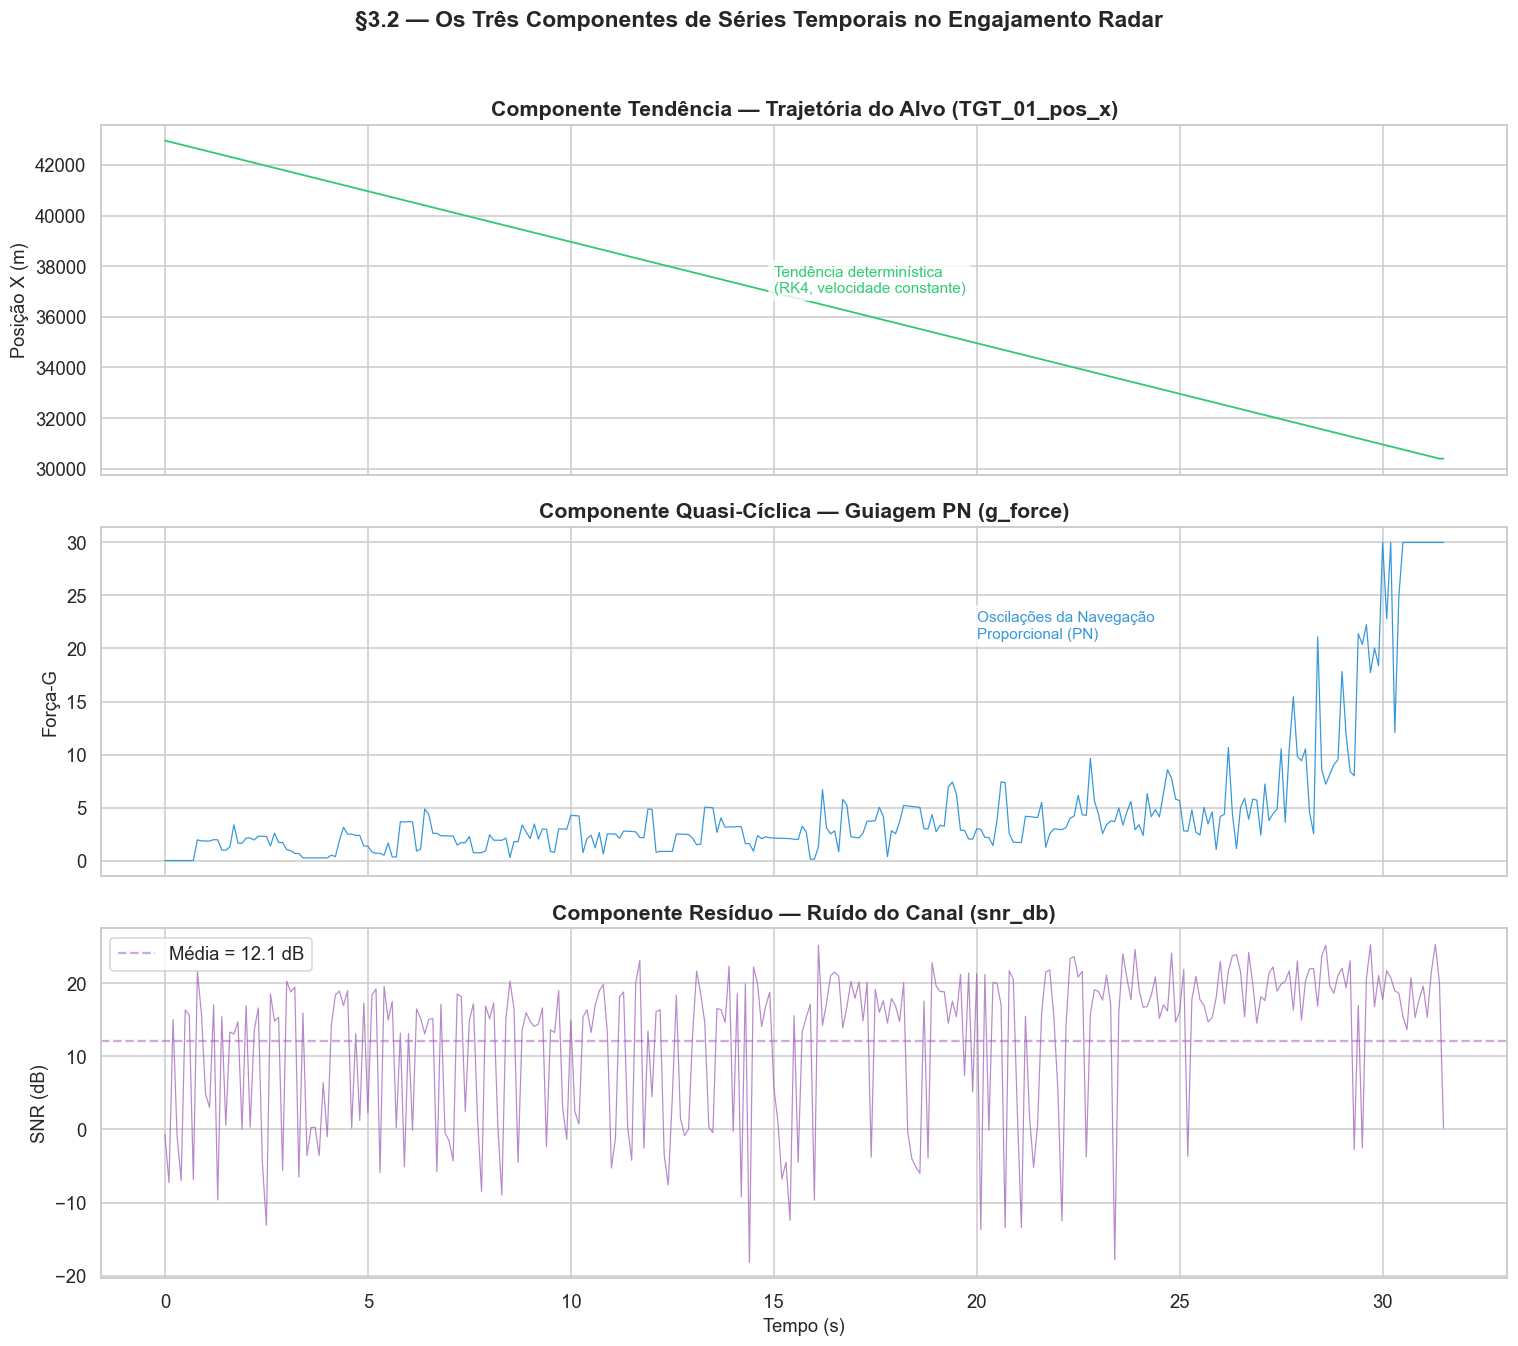

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Componente Tendência: TGT_01_pos_x
pos_x = df['TGT_01_pos_x'].values
axes[0].plot(time, pos_x, color=COLORS['trend'], linewidth=1.2)
axes[0].set_ylabel('Posição X (m)')
axes[0].set_title('Componente Tendência — Trajetória do Alvo (TGT_01_pos_x)', fontweight='bold')
axes[0].annotate('Tendência determinística\n(RK4, velocidade constante)', 
                 xy=(15, pos_x[150]), fontsize=10, color=COLORS['trend'],
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Componente "Sazonal": g_force (oscilações da guiagem)
gforce = df['g_force'].values
axes[1].plot(time, gforce, color=COLORS['gforce'], linewidth=0.8)
axes[1].set_ylabel('Força-G')
axes[1].set_title('Componente Quasi-Cíclica — Guiagem PN (g_force)', fontweight='bold')
axes[1].annotate('Oscilações da Navegação\nProporcional (PN)', 
                 xy=(20, max(gforce)*0.7), fontsize=10, color=COLORS['gforce'],
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Componente Resíduo: snr_db (ruído)
axes[2].plot(time, snr, color=COLORS['noise'], linewidth=0.8, alpha=0.7)
axes[2].axhline(snr.mean(), color=COLORS['noise'], linestyle='--', alpha=0.5,
                label=f'Média = {snr.mean():.1f} dB')
axes[2].set_ylabel('SNR (dB)')
axes[2].set_xlabel('Tempo (s)')
axes[2].set_title('Componente Resíduo — Ruído do Canal (snr_db)', fontweight='bold')
axes[2].legend()

plt.suptitle('§3.2 — Os Três Componentes de Séries Temporais no Engajamento Radar', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.2.2 — Decomposição Conceitual: Sinal = Determinístico + Estocástico

Para dados radar, a decomposição natural é:

$$\text{Sinal Observado} = \underbrace{\text{Sinal Determinístico}}_{T_t} + \underbrace{\text{Ruído Estocástico}}_{R_t}$$

Demonstramos isto com a `miss_distance_m`, onde a tendência é a convergência balística e o resíduo são perturbações da guiagem.

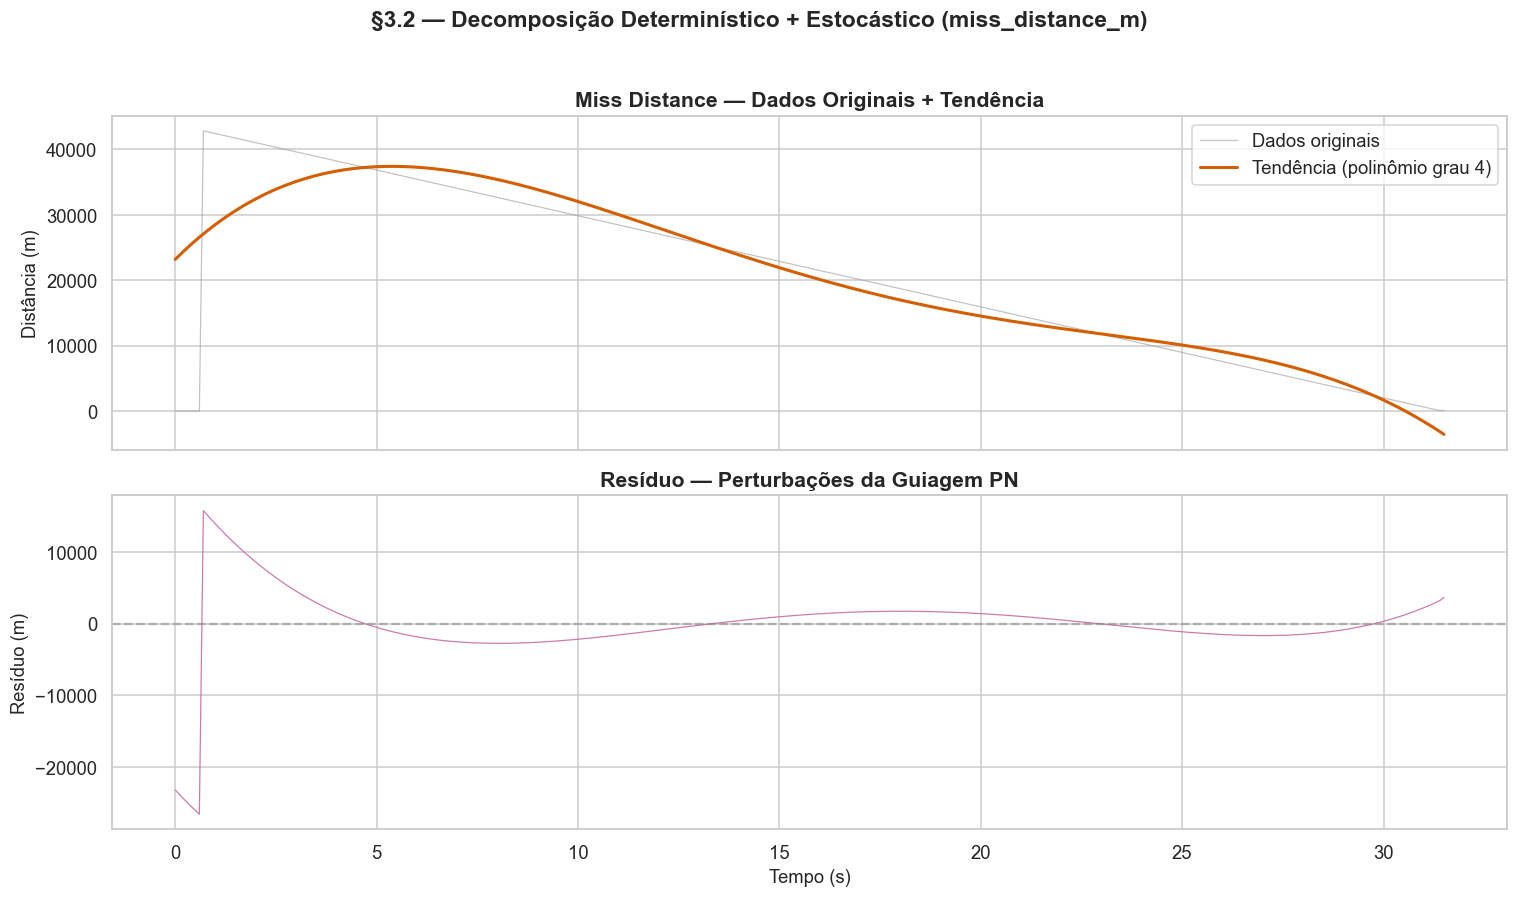

Variância dos dados originais: 161078631.97 m²
Variância da tendência:        137112413.18 m²
Variância do resíduo:          23966218.79 m²

→ A tendência explica 85.1% da variância total.


In [8]:
miss = df['miss_distance_m'].values

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Série original com tendência polinomial
z = np.polyfit(time, miss, deg=4)
trend_poly = np.polyval(z, time)
residual = miss - trend_poly

axes[0].plot(time, miss, color=COLORS['original'], alpha=0.6, linewidth=0.8,
             label='Dados originais')
axes[0].plot(time, trend_poly, color=COLORS['ma'], linewidth=2,
             label='Tendência (polinômio grau 4)')
axes[0].set_ylabel('Distância (m)')
axes[0].set_title('Miss Distance — Dados Originais + Tendência', fontweight='bold')
axes[0].legend()

# Resíduo
axes[1].plot(time, residual, color=COLORS['remainder'], linewidth=0.8)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Resíduo (m)')
axes[1].set_xlabel('Tempo (s)')
axes[1].set_title('Resíduo — Perturbações da Guiagem PN', fontweight='bold')

plt.suptitle('§3.2 — Decomposição Determinístico + Estocástico (miss_distance_m)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Variância dos dados originais: {np.var(miss):.2f} m²")
print(f"Variância da tendência:        {np.var(trend_poly):.2f} m²")
print(f"Variância do resíduo:          {np.var(residual):.2f} m²")
pct = np.var(trend_poly) / np.var(miss) * 100
print(f"\n→ A tendência explica {pct:.1f}% da variância total.")

---
## §3.3 — Médias Móveis

A média móvel de ordem $m$ é definida como:

$$\hat{T}_t = \frac{1}{m} \sum_{j=-k}^{k} y_{t+j}, \quad m = 2k+1$$

As médias móveis eliminam a aleatoriedade, revelando a **componente tendência-ciclo** suavizada. A escolha da ordem $m$ controla o grau de suavização:
- **$m$ pequeno**: mais responsivo, menos suavização
- **$m$ grande**: mais suave, maior atraso

> **Contexto Radar**: A suavização por MA é análoga a um **filtro passa-baixas** temporal aplicado ao sinal radar. Diferentes ordens de MA correspondem a diferentes larguras de banda do filtro.

### 3.3.1 — Médias Móveis de Diferentes Ordens sobre o SNR

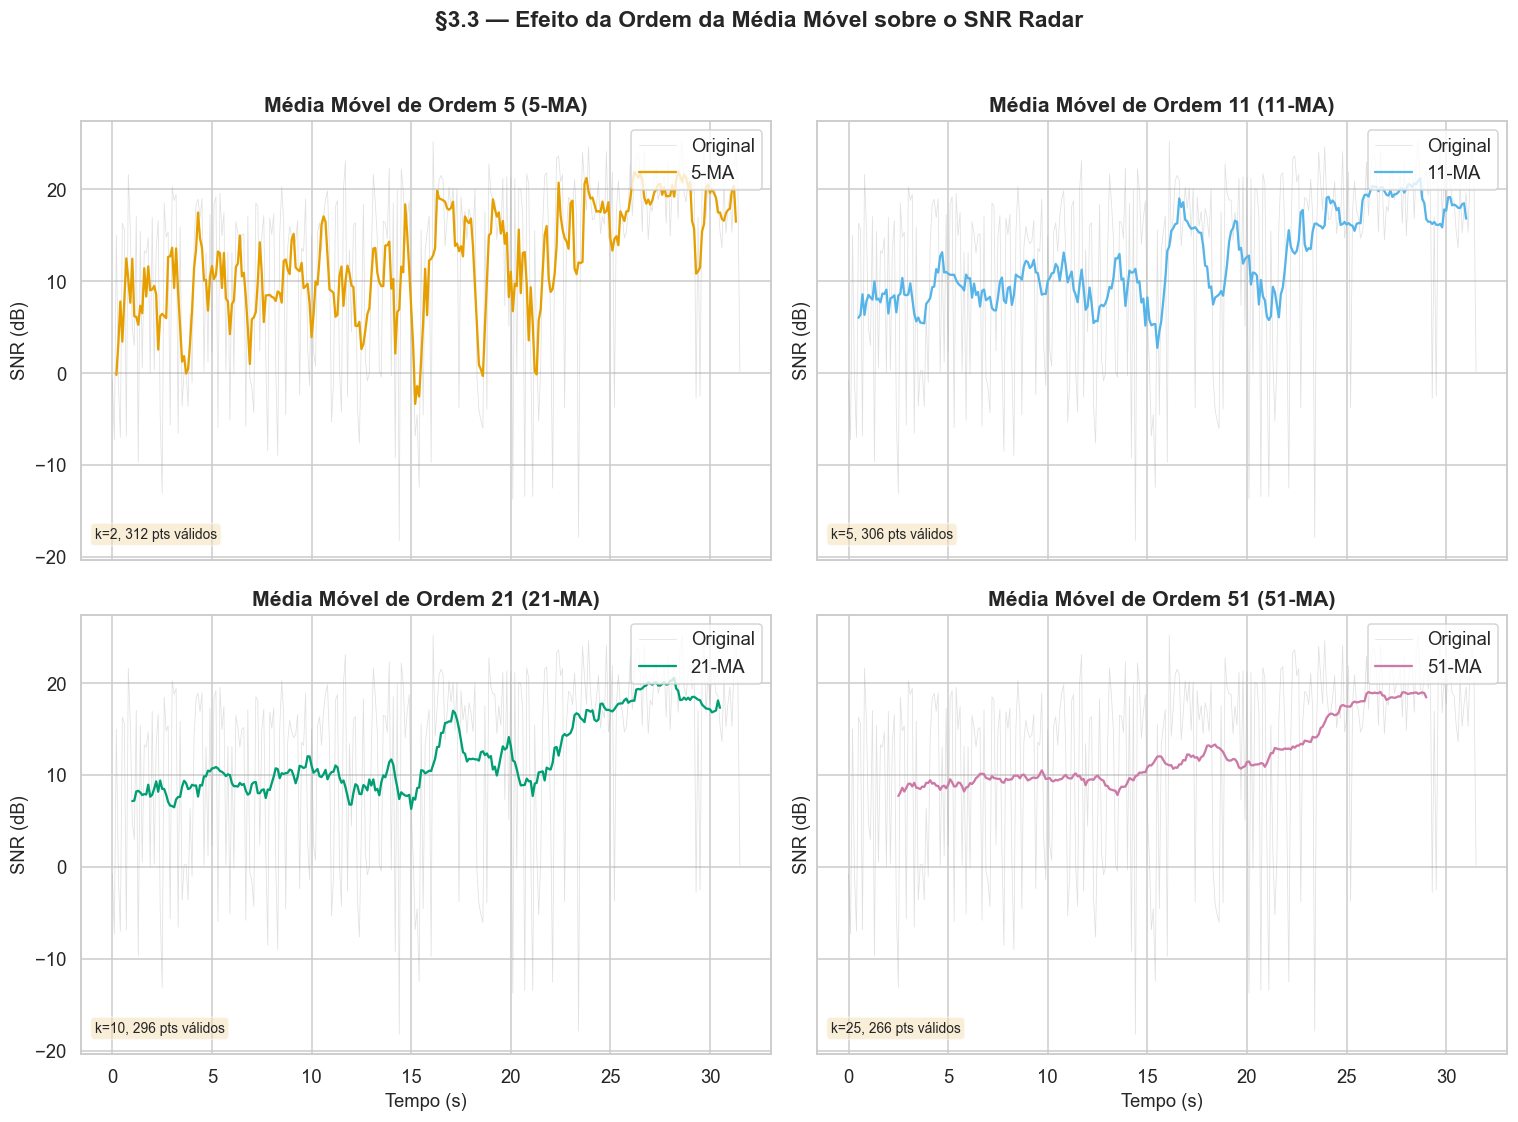

Resumo — Energia do resíduo por ordem de MA:
   Ordem    Var. Resíduo   Redução (%)
----------------------------------------
       5         69.8350         32.6%
      11         83.3910         19.6%
      21         87.2763         15.8%
      51         92.4312         10.8%


In [9]:
# Calcular médias móveis de diferentes ordens
orders = [5, 11, 21, 51]
snr_series = pd.Series(snr, index=time)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()

ma_colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']

for i, m in enumerate(orders):
    ma = snr_series.rolling(window=m, center=True).mean()
    
    axes[i].plot(time, snr, color=COLORS['original'], alpha=0.3, linewidth=0.5,
                label='Original')
    axes[i].plot(time, ma.values, color=ma_colors[i], linewidth=1.5,
                label=f'{m}-MA')
    axes[i].set_title(f'Média Móvel de Ordem {m} ({m}-MA)', fontweight='bold')
    axes[i].set_ylabel('SNR (dB)')
    axes[i].legend(loc='upper right')
    
    # Calcular perda de dados nas bordas
    k = m // 2
    valid = ma.notna().sum()
    axes[i].annotate(f'k={k}, {valid} pts válidos', xy=(0.02, 0.05), 
                     xycoords='axes fraction', fontsize=9, 
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[2].set_xlabel('Tempo (s)')
axes[3].set_xlabel('Tempo (s)')

plt.suptitle('§3.3 — Efeito da Ordem da Média Móvel sobre o SNR Radar', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Resumo — Energia do resíduo por ordem de MA:")
print(f"{'Ordem':>8} {'Var. Resíduo':>15} {'Redução (%)':>13}")
print("-" * 40)
var_orig = np.var(snr)
for m in orders:
    ma = snr_series.rolling(window=m, center=True).mean()
    residual_ma = snr_series - ma
    var_res = residual_ma.dropna().var()
    reduction = (1 - var_res / var_orig) * 100
    print(f"{m:>8} {var_res:>15.4f} {reduction:>12.1f}%")

### 3.3.2 — Comparação de MAs: SNR vs. Tendência (Todas as Ordens)

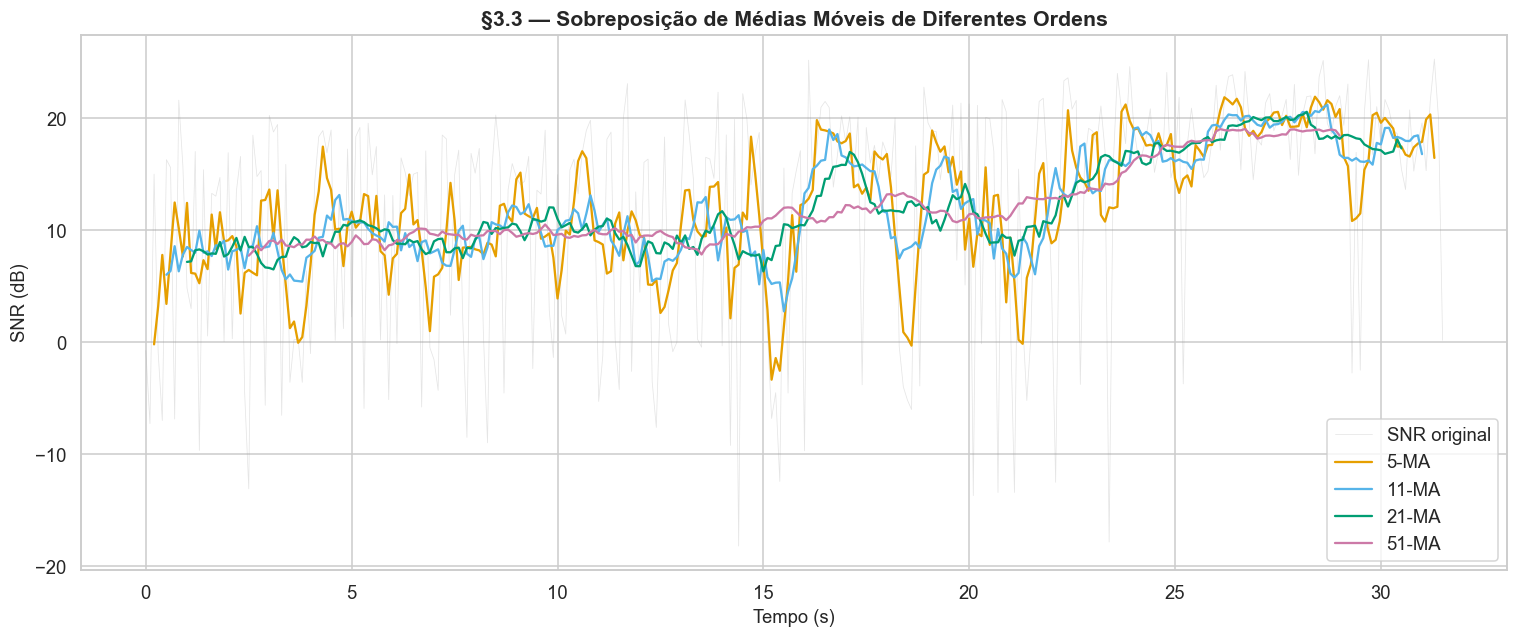

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(time, snr, color=COLORS['original'], alpha=0.25, linewidth=0.5, 
        label='SNR original')

for i, m in enumerate(orders):
    ma = snr_series.rolling(window=m, center=True).mean()
    ax.plot(time, ma.values, color=ma_colors[i], linewidth=1.5, 
            label=f'{m}-MA')

ax.set_xlabel('Tempo (s)')
ax.set_ylabel('SNR (dB)')
ax.set_title('§3.3 — Sobreposição de Médias Móveis de Diferentes Ordens', 
             fontweight='bold')
ax.legend(loc='best')

plt.tight_layout()
plt.show()

### 3.3.3 — Média Móvel Centrada 2×m-MA (Médias Móveis de Médias Móveis)

Para tornar uma MA de ordem par simétrica, aplica-se uma 2-MA sobre a m-MA original. O resultado é uma **média móvel ponderada** centrada:

$$\hat{T}_t = \frac{1}{8}y_{t-2} + \frac{1}{4}y_{t-1} + \frac{1}{4}y_t + \frac{1}{4}y_{t+1} + \frac{1}{8}y_{t+2} \quad \text{(2×4-MA)}$$

No contexto radar, demonstramos com a `g_force` do interceptador.

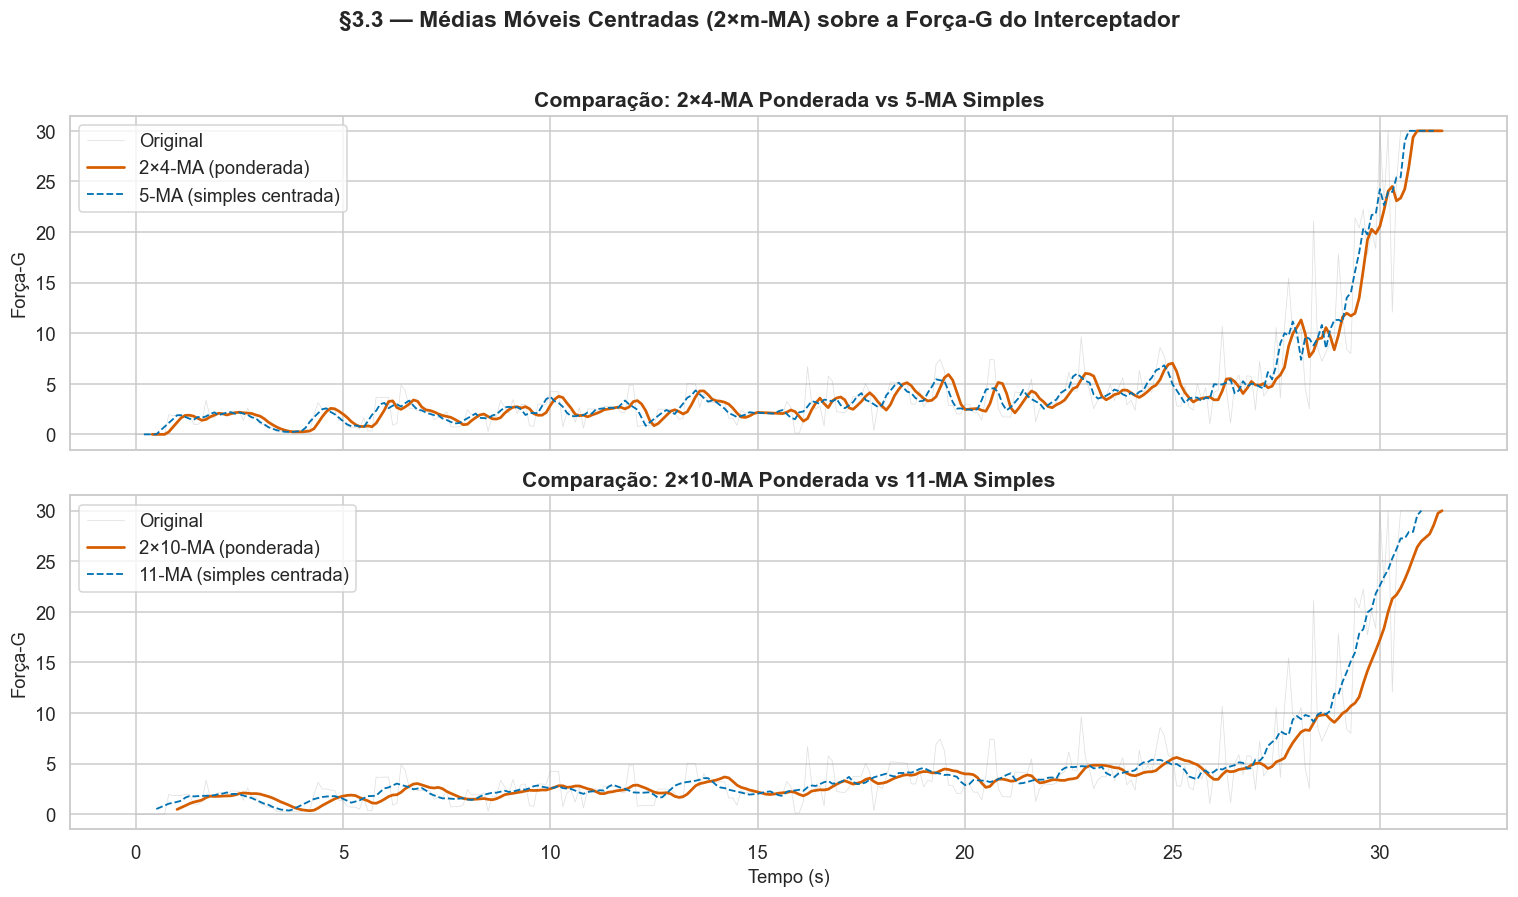

→ A 2×m-MA produz curvas ligeiramente mais suaves que a MA simples equivalente,
  pois os pesos de borda (1/2m) atenuam descontinuidades na janela.


In [11]:
gforce_series = pd.Series(gforce, index=time)

# 4-MA (não centrada) seguida de 2-MA (centrando)
ma_4 = gforce_series.rolling(window=4, center=False).mean()
ma_2x4 = ma_4.rolling(window=2, center=True).mean()

# 10-MA (não centrada) seguida de 2-MA (centrando)
ma_10 = gforce_series.rolling(window=10, center=False).mean()
ma_2x10 = ma_10.rolling(window=2, center=True).mean()

# MA simples centradas equivalentes para comparação
ma_5_centered = gforce_series.rolling(window=5, center=True).mean()
ma_11_centered = gforce_series.rolling(window=11, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 2x4-MA vs 5-MA
axes[0].plot(time, gforce, color=COLORS['original'], alpha=0.3, linewidth=0.5,
             label='Original')
axes[0].plot(time, ma_2x4.values, color=COLORS['ma'], linewidth=1.8,
             label='2×4-MA (ponderada)')
axes[0].plot(time, ma_5_centered.values, color=COLORS['seasonal'], linewidth=1.2, 
             linestyle='--', label='5-MA (simples centrada)')
axes[0].set_ylabel('Força-G')
axes[0].set_title('Comparação: 2×4-MA Ponderada vs 5-MA Simples', fontweight='bold')
axes[0].legend()

# 2x10-MA vs 11-MA
axes[1].plot(time, gforce, color=COLORS['original'], alpha=0.3, linewidth=0.5,
             label='Original')
axes[1].plot(time, ma_2x10.values, color=COLORS['ma'], linewidth=1.8,
             label='2×10-MA (ponderada)')
axes[1].plot(time, ma_11_centered.values, color=COLORS['seasonal'], linewidth=1.2, 
             linestyle='--', label='11-MA (simples centrada)')
axes[1].set_ylabel('Força-G')
axes[1].set_xlabel('Tempo (s)')
axes[1].set_title('Comparação: 2×10-MA Ponderada vs 11-MA Simples', fontweight='bold')
axes[1].legend()

plt.suptitle('§3.3 — Médias Móveis Centradas (2×m-MA) sobre a Força-G do Interceptador', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("→ A 2×m-MA produz curvas ligeiramente mais suaves que a MA simples equivalente,")
print("  pois os pesos de borda (1/2m) atenuam descontinuidades na janela.")

### 3.3.4 — Média Móvel Ponderada (WMA) — Pesos Customizados

Uma média móvel ponderada permite dar mais importância às observações centrais:

$$\hat{T}_t = \sum_{j=-k}^{k} a_j \, y_{t+j}, \quad \sum a_j = 1, \quad a_j = a_{-j}$$

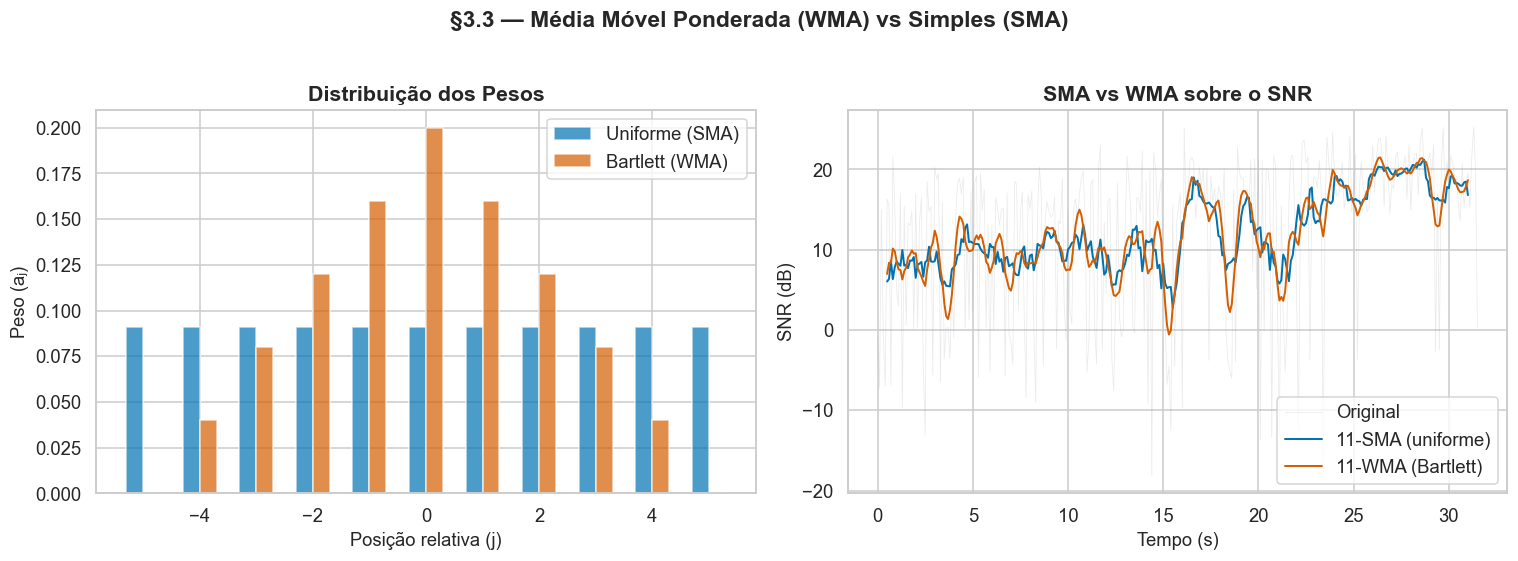

→ A WMA com pesos Bartlett produz uma estimativa mais suave da tendência,
  pois observações centrais recebem peso maior — reduzindo descontinuidades.


In [12]:
def weighted_moving_average(series, weights):
    """Calcula média móvel ponderada com pesos simétricos."""
    m = len(weights)
    result = np.full_like(series, np.nan, dtype=float)
    k = m // 2
    for t in range(k, len(series) - k):
        result[t] = np.sum(weights * series[t-k:t+k+1])
    return result

# Pesos triangulares (Bartlett) de ordem 11
m = 11
k = m // 2
bartlett = np.bartlett(m)
bartlett /= bartlett.sum()  # Normalizar para soma = 1

# Pesos uniformes (SMA) de ordem 11 para comparação
uniform = np.ones(m) / m

wma_bartlett = weighted_moving_average(snr, bartlett)
wma_uniform = weighted_moving_average(snr, uniform)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visualizar pesos
x_weights = np.arange(-k, k+1)
axes[0].bar(x_weights - 0.15, uniform, width=0.3, color=COLORS['seasonal'], 
            alpha=0.7, label='Uniforme (SMA)')
axes[0].bar(x_weights + 0.15, bartlett, width=0.3, color=COLORS['ma'], 
            alpha=0.7, label='Bartlett (WMA)')
axes[0].set_xlabel('Posição relativa (j)')
axes[0].set_ylabel('Peso (aⱼ)')
axes[0].set_title('Distribuição dos Pesos', fontweight='bold')
axes[0].legend()

# Comparar resultados
axes[1].plot(time, snr, color=COLORS['original'], alpha=0.2, linewidth=0.5,
             label='Original')
axes[1].plot(time, wma_uniform, color=COLORS['seasonal'], linewidth=1.3,
             label='11-SMA (uniforme)')
axes[1].plot(time, wma_bartlett, color=COLORS['ma'], linewidth=1.3,
             label='11-WMA (Bartlett)')
axes[1].set_xlabel('Tempo (s)')
axes[1].set_ylabel('SNR (dB)')
axes[1].set_title('SMA vs WMA sobre o SNR', fontweight='bold')
axes[1].legend()

plt.suptitle('§3.3 — Média Móvel Ponderada (WMA) vs Simples (SMA)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("→ A WMA com pesos Bartlett produz uma estimativa mais suave da tendência,")
print("  pois observações centrais recebem peso maior — reduzindo descontinuidades.")

---
## §3.4 — Decomposição Clássica

A decomposição clássica assume:
1. A componente sazonal é **constante** ao longo do tempo
2. A tendência é obtida por MA de ordem igual ao período sazonal
3. O resíduo é $R_t = y_t - T_t - S_t$ (aditivo)

Para os dados radar de 10 Hz sem sazonalidade calendárica, definimos um **período artificial** baseado na física do problema: utilizamos `period=10` (equivalente a 1 segundo de dados), o que permite capturar oscilações sub-segundo na guiagem.

> **Limitações do método clássico** (FPP3 §3.4):
> - Não estima a tendência nas bordas (primeiras/últimas $k$ observações)
> - Assume sazonalidade constante
> - Não é robusto a outliers

### 3.4.1 — Decomposição Clássica Aditiva do SNR

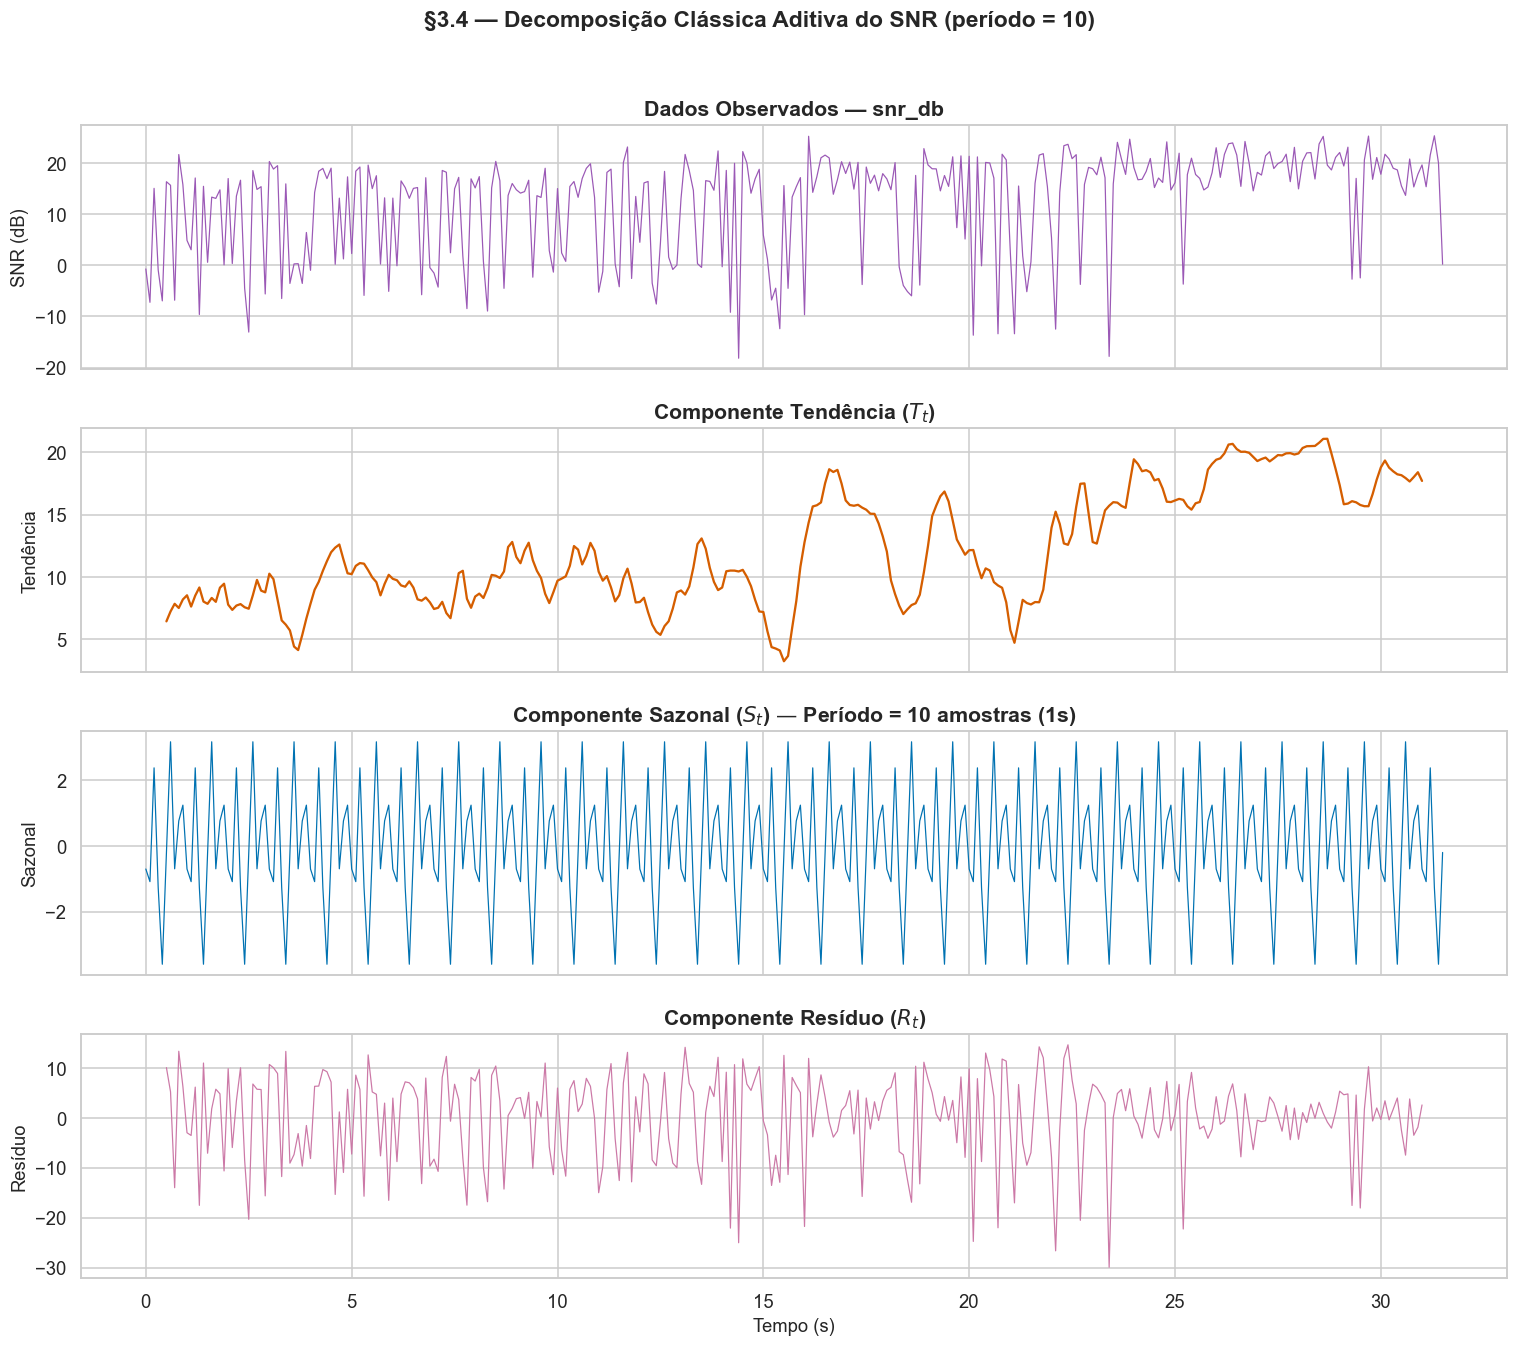

Erro máximo de reconstrução: 4.44e-15 (deve ser ≈ 0)
Observações sem tendência (bordas): 10 de 316


In [13]:
# Criar série com índice temporal
snr_ts = pd.Series(snr, index=pd.RangeIndex(len(snr)), name='SNR (dB)')

# Decomposição clássica aditiva com período = 10 (1 segundo @ 10Hz)
period = 10
decomp_classical = seasonal_decompose(snr_ts, model='additive', period=period)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Painel 1: Dados observados
axes[0].plot(time, snr, color=COLORS['noise'], linewidth=0.8)
axes[0].set_ylabel('SNR (dB)')
axes[0].set_title('Dados Observados — snr_db', fontweight='bold')

# Painel 2: Tendência
axes[1].plot(time, decomp_classical.trend, color=COLORS['ma'], linewidth=1.5)
axes[1].set_ylabel('Tendência')
axes[1].set_title('Componente Tendência ($T_t$)', fontweight='bold')

# Painel 3: Sazonalidade
axes[2].plot(time, decomp_classical.seasonal, color=COLORS['seasonal'], linewidth=0.8)
axes[2].set_ylabel('Sazonal')
axes[2].set_title(f'Componente Sazonal ($S_t$) — Período = {period} amostras (1s)', fontweight='bold')

# Painel 4: Resíduo
axes[3].plot(time, decomp_classical.resid, color=COLORS['remainder'], linewidth=0.8)
axes[3].set_ylabel('Resíduo')
axes[3].set_xlabel('Tempo (s)')
axes[3].set_title('Componente Resíduo ($R_t$)', fontweight='bold')

plt.suptitle(f'§3.4 — Decomposição Clássica Aditiva do SNR (período = {period})', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Verificar que trend + seasonal + resid ≈ original
valid = ~np.isnan(decomp_classical.trend)
recon = (decomp_classical.trend[valid] + decomp_classical.seasonal[valid] + 
         decomp_classical.resid[valid])
error = np.max(np.abs(recon - snr[valid]))
print(f"Erro máximo de reconstrução: {error:.2e} (deve ser ≈ 0)")
print(f"Observações sem tendência (bordas): {(~valid).sum()} de {len(snr)}")

### 3.4.2 — Decomposição Clássica da Miss Distance

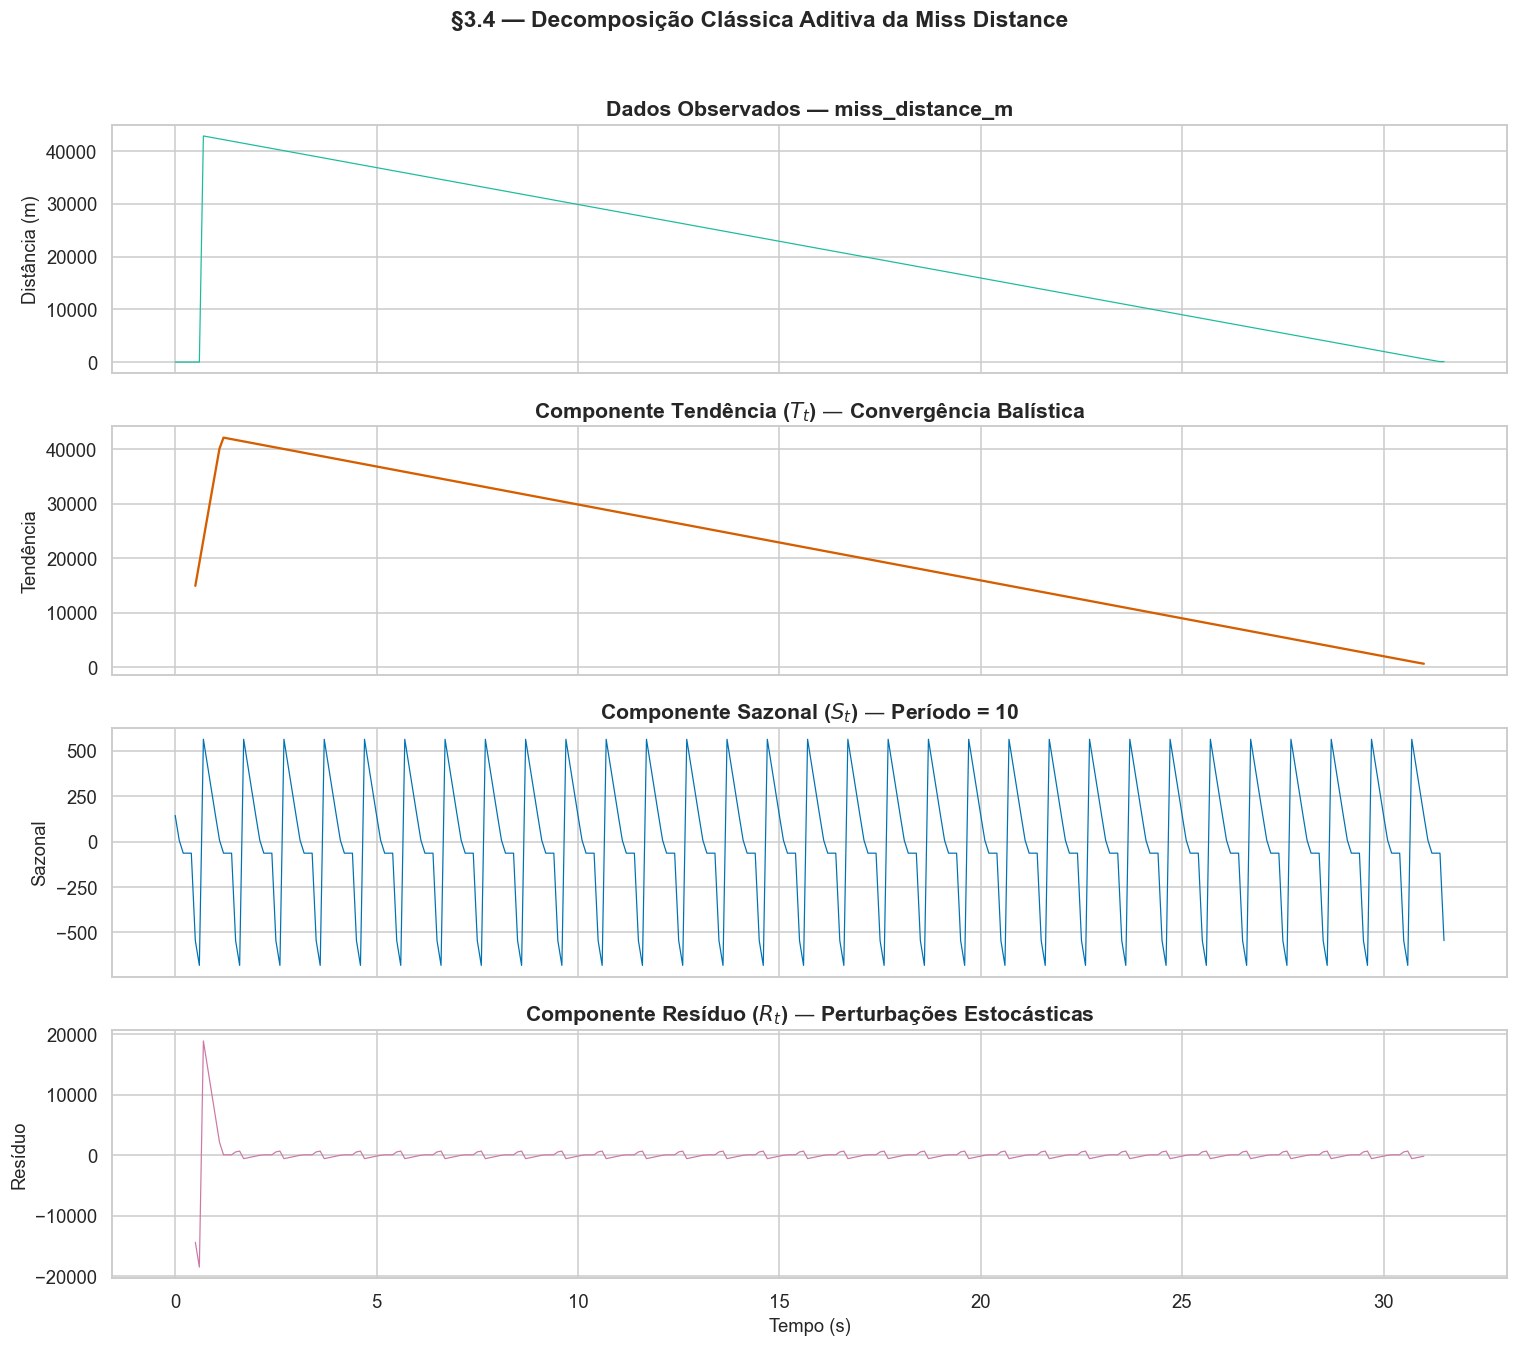

In [14]:
miss_ts = pd.Series(miss, index=pd.RangeIndex(len(miss)), name='Miss Distance (m)')

# Decomposição clássica com período = 10
decomp_miss = seasonal_decompose(miss_ts, model='additive', period=period)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(time, miss, color=COLORS['miss'], linewidth=0.8)
axes[0].set_ylabel('Distância (m)')
axes[0].set_title('Dados Observados — miss_distance_m', fontweight='bold')

axes[1].plot(time, decomp_miss.trend, color=COLORS['ma'], linewidth=1.5)
axes[1].set_ylabel('Tendência')
axes[1].set_title('Componente Tendência ($T_t$) — Convergência Balística', fontweight='bold')

axes[2].plot(time, decomp_miss.seasonal, color=COLORS['seasonal'], linewidth=0.8)
axes[2].set_ylabel('Sazonal')
axes[2].set_title(f'Componente Sazonal ($S_t$) — Período = {period}', fontweight='bold')

axes[3].plot(time, decomp_miss.resid, color=COLORS['remainder'], linewidth=0.8)
axes[3].set_ylabel('Resíduo')
axes[3].set_xlabel('Tempo (s)')
axes[3].set_title('Componente Resíduo ($R_t$) — Perturbações Estocásticas', fontweight='bold')

plt.suptitle('§3.4 — Decomposição Clássica Aditiva da Miss Distance', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.4.3 — Dados Dessazonalizados

O FPP3 (§3.2) define dados dessazonalizados como $y_t - S_t$ (aditivo). Removendo a componente sazonal, visualizamos apenas a tendência e as flutuações irregulares.

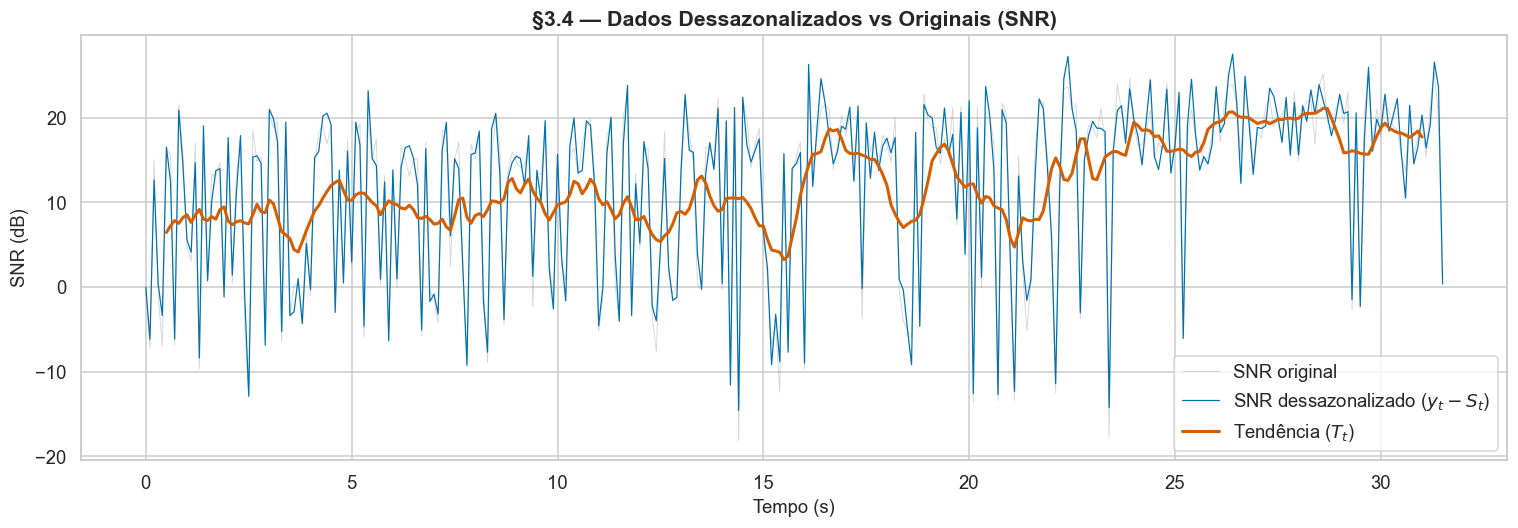

→ Os dados dessazonalizados contêm a tendência + resíduo.
  No contexto radar, remover a 'sazonalidade' (período de 1s) equivale
  a aplicar um filtro que atenua oscilações regulares no sinal.


In [15]:
# Dados dessazonalizados
snr_sa = snr - decomp_classical.seasonal

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(time, snr, color=COLORS['original'], alpha=0.4, linewidth=0.6, 
        label='SNR original')
ax.plot(time, snr_sa, color=COLORS['seasonal'], linewidth=0.8, 
        label='SNR dessazonalizado ($y_t - S_t$)')
valid_trend = ~np.isnan(decomp_classical.trend)
ax.plot(time[valid_trend], decomp_classical.trend[valid_trend], 
        color=COLORS['ma'], linewidth=2, label='Tendência ($T_t$)')

ax.set_xlabel('Tempo (s)')
ax.set_ylabel('SNR (dB)')
ax.set_title('§3.4 — Dados Dessazonalizados vs Originais (SNR)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print("→ Os dados dessazonalizados contêm a tendência + resíduo.")
print("  No contexto radar, remover a 'sazonalidade' (período de 1s) equivale")
print("  a aplicar um filtro que atenua oscilações regulares no sinal.")

---
## §3.6 — Decomposição STL

**STL** (*Seasonal and Trend decomposition using Loess*) é um método mais robusto e flexível que a decomposição clássica:

- Permite que a componente sazonal **varie ao longo do tempo**
- O grau de suavização é controlado por dois parâmetros:
  - `seasonal`: janela sazonal (valores maiores = sazonalidade mais estável)
  - `trend`: janela de tendência (valores maiores = tendência mais suave)
- Pode ser **robusto a outliers** (`robust=True`)

#### Vantagens sobre a decomposição clássica:
1. Funciona com qualquer tipo de sazonalidade (não só mensal/trimestral)
2. A sazonalidade pode evoluir
3. Robusto a observações atípicas
4. Estima a tendência inclusive nas bordas

### 3.6.1 — STL Decomposition do SNR

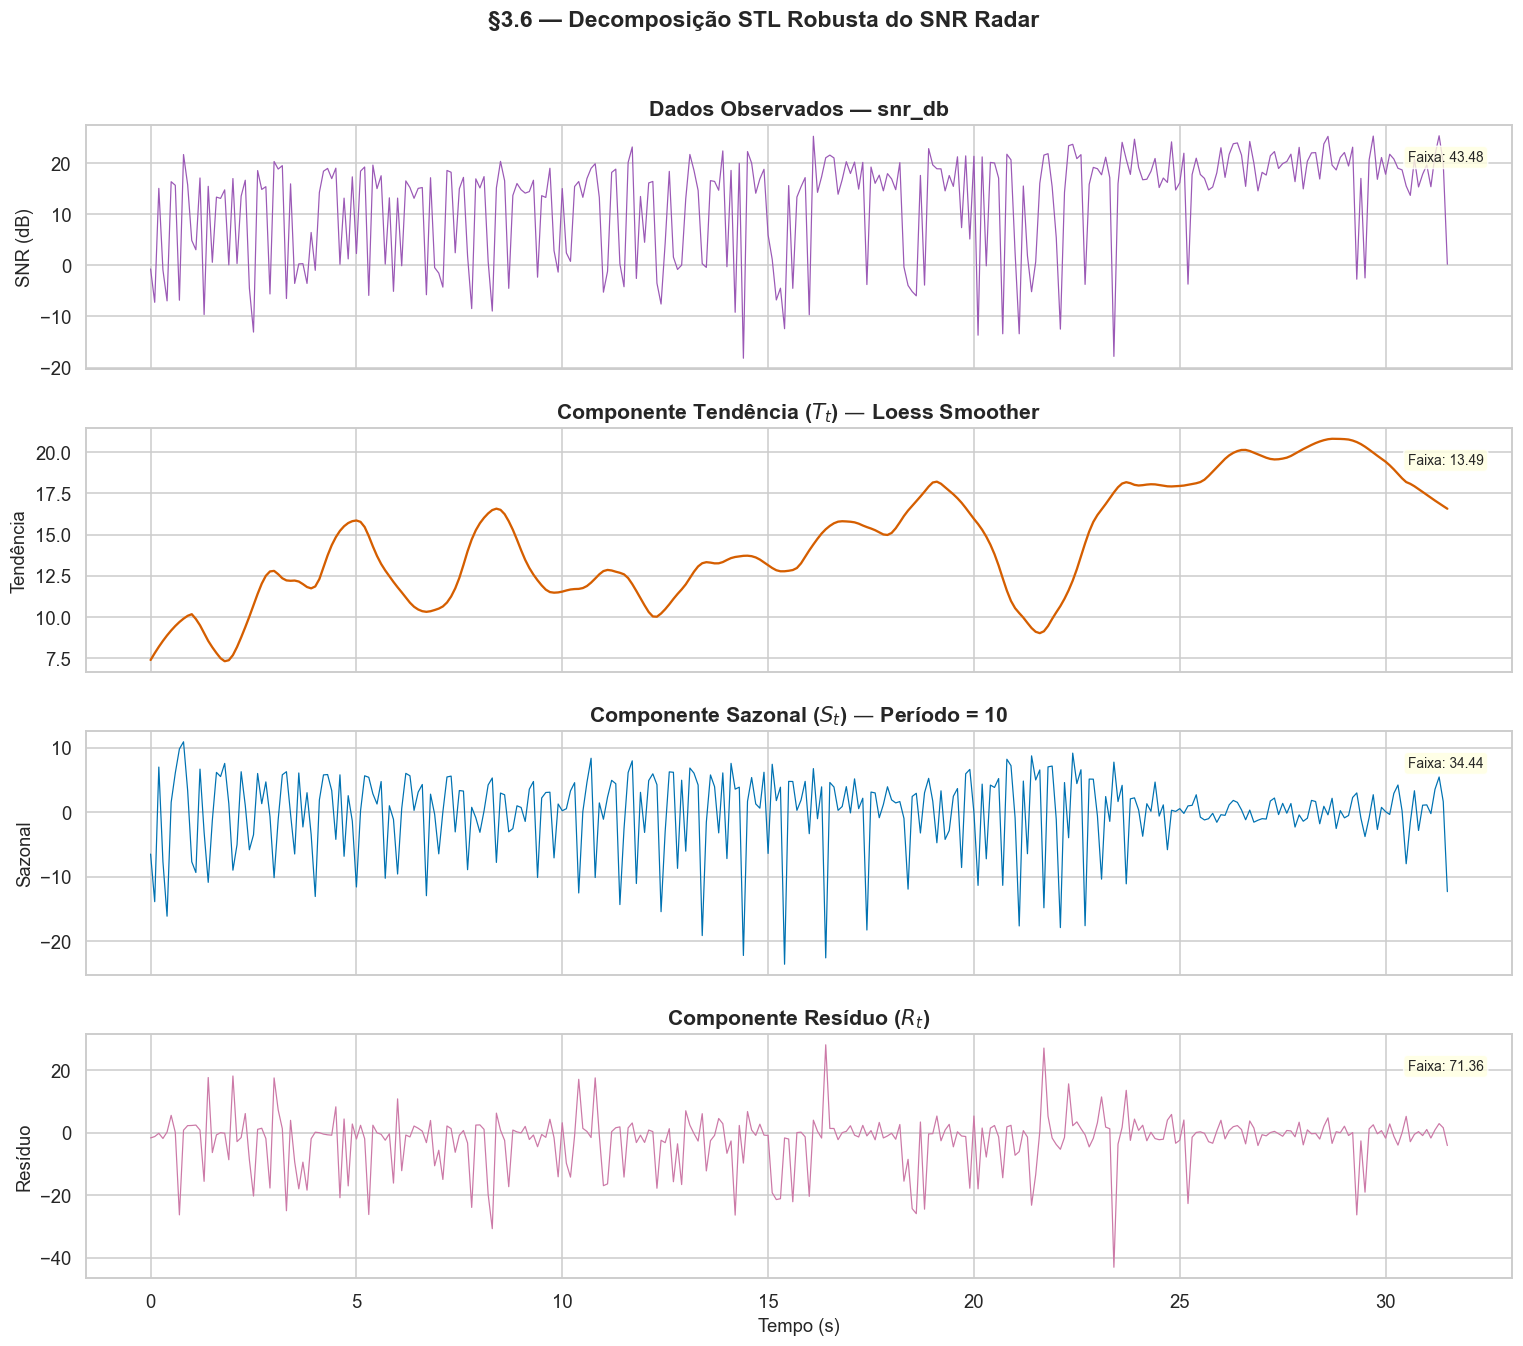


Força da Tendência (F_T):     0.1585
Força da Sazonalidade (F_S):  0.1443

→ Tendência fraca, sazonalidade fraca


In [16]:
# STL com parâmetros padrão
stl_result = STL(snr_ts, period=period, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(time, snr, color=COLORS['noise'], linewidth=0.8)
axes[0].set_ylabel('SNR (dB)')
axes[0].set_title('Dados Observados — snr_db', fontweight='bold')

axes[1].plot(time, stl_result.trend, color=COLORS['ma'], linewidth=1.5)
axes[1].set_ylabel('Tendência')
axes[1].set_title('Componente Tendência ($T_t$) — Loess Smoother', fontweight='bold')

axes[2].plot(time, stl_result.seasonal, color=COLORS['seasonal'], linewidth=0.8)
axes[2].set_ylabel('Sazonal')
axes[2].set_title(f'Componente Sazonal ($S_t$) — Período = {period}', fontweight='bold')

axes[3].plot(time, stl_result.resid, color=COLORS['remainder'], linewidth=0.8)
axes[3].set_ylabel('Resíduo')
axes[3].set_xlabel('Tempo (s)')
axes[3].set_title('Componente Resíduo ($R_t$)', fontweight='bold')

# Adicionar barras de escala relativa (como no FPP3)
for i, (vals, label) in enumerate([
    (snr, 'Dados'), (stl_result.trend, 'Tendência'), 
    (stl_result.seasonal, 'Sazonal'), (stl_result.resid, 'Resíduo')
]):
    valid_vals = vals[~np.isnan(vals)] if hasattr(vals, '__len__') else vals
    rng = np.ptp(valid_vals)
    axes[i].annotate(f'Faixa: {rng:.2f}', xy=(0.98, 0.85), 
                     xycoords='axes fraction', ha='right', fontsize=9,
                     bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('§3.6 — Decomposição STL Robusta do SNR Radar', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Força dos componentes (como no FPP3 §4.3)
var_resid = np.var(stl_result.resid)
var_sa = np.var(stl_result.resid + stl_result.trend)  # season-adjusted
var_dt = np.var(stl_result.resid + stl_result.seasonal)  # detrended
F_trend = max(0, 1 - var_resid / var_sa)
F_seasonal = max(0, 1 - var_resid / var_dt)

print(f"\nForça da Tendência (F_T):     {F_trend:.4f}")
print(f"Força da Sazonalidade (F_S):  {F_seasonal:.4f}")
print(f"\n→ {'Forte tendência' if F_trend > 0.5 else 'Tendência fraca'}, "
      f"{'forte sazonalidade' if F_seasonal > 0.5 else 'sazonalidade fraca'}")

### 3.6.2 — Efeito dos Parâmetros STL: Janela Sazonal e Tendência

O FPP3 enfatiza que os dois parâmetros principais do STL controlam a flexibilidade:
- **seasonal** pequeno: sazonalidade muda rapidamente
- **seasonal** grande ou `'periodic'`: sazonalidade fixa
- **trend** pequeno: tendência mais flexível (reage a mudanças rápidas)
- **trend** grande: tendência mais suave

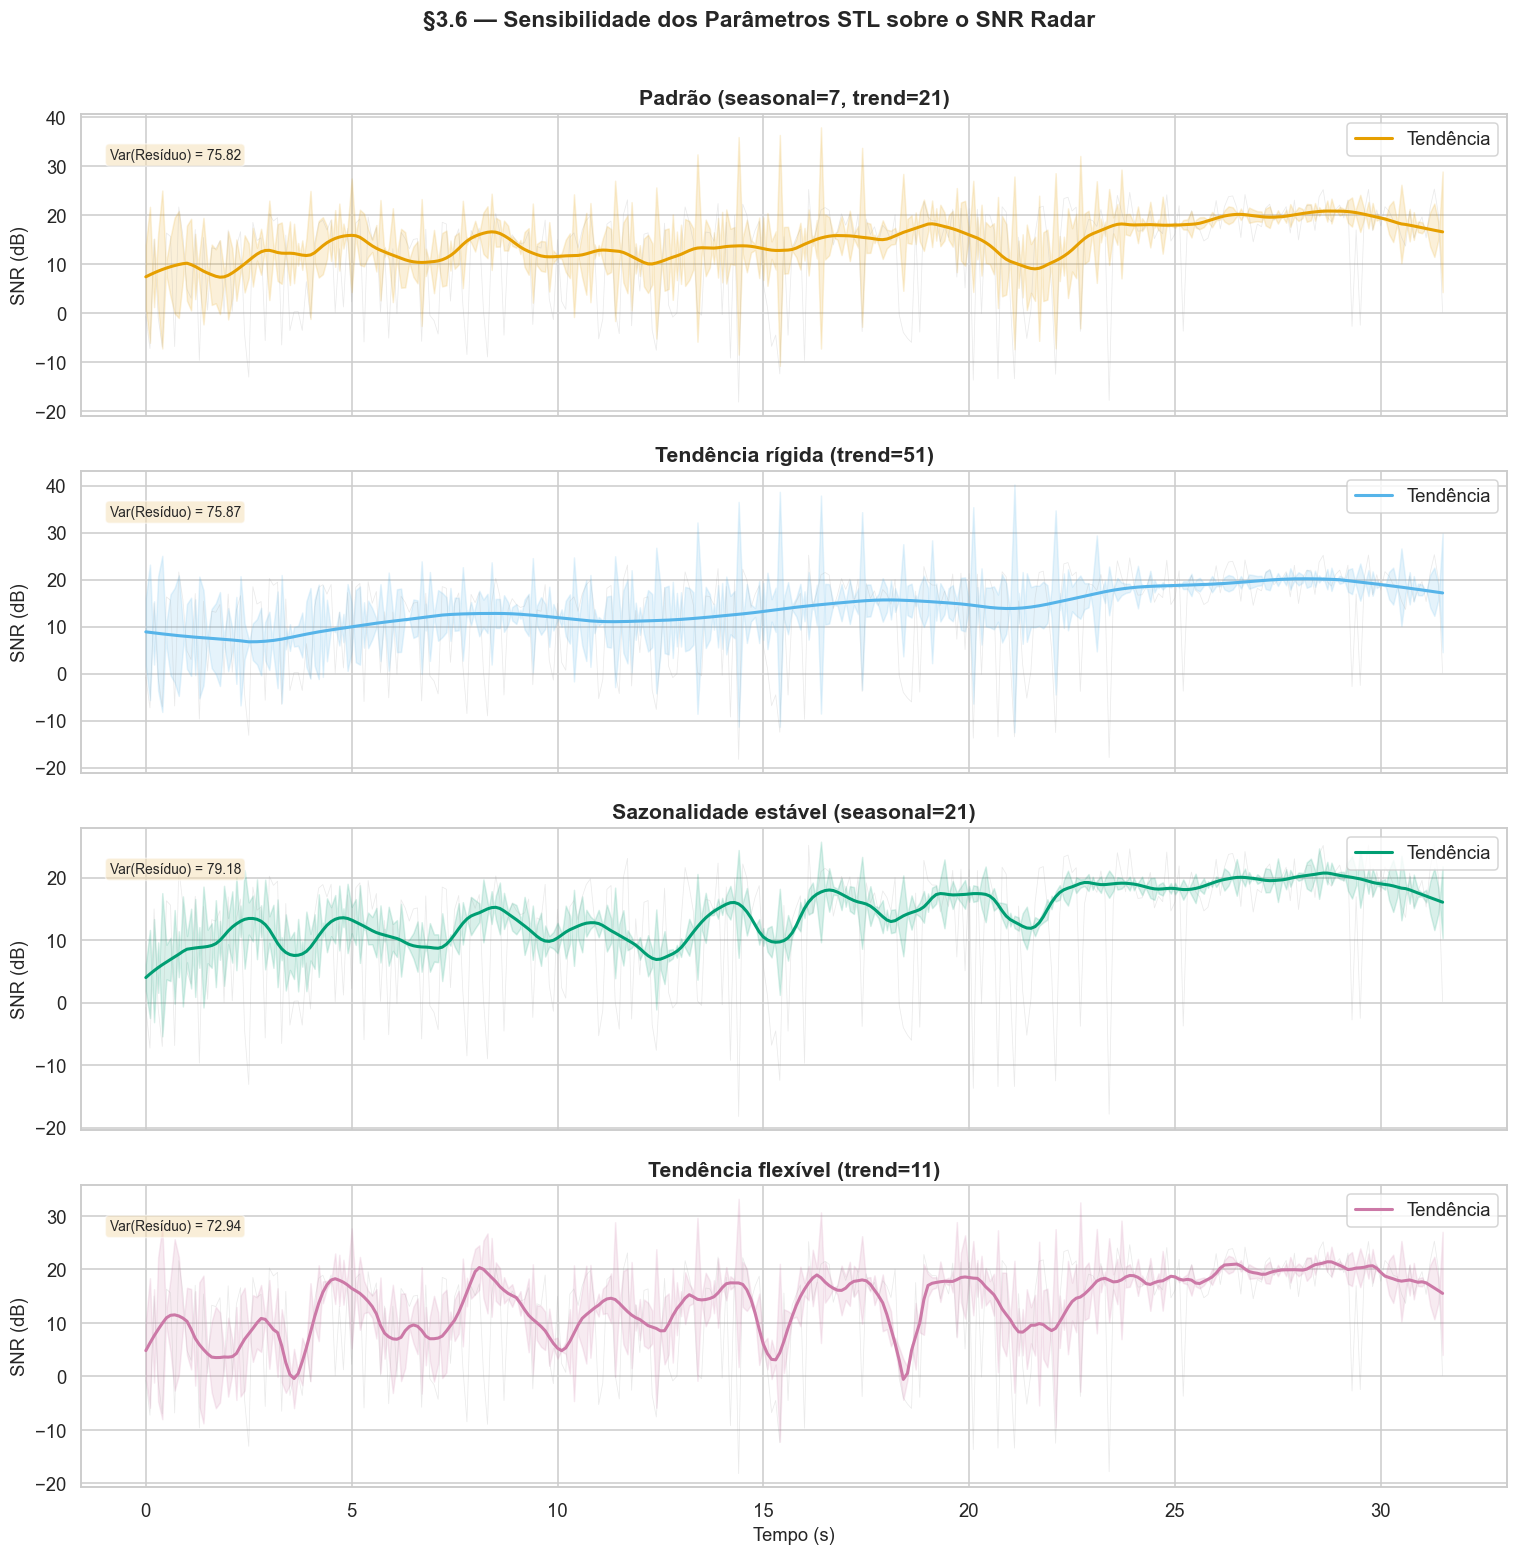

In [17]:
configs = [
    {'seasonal': 7,  'trend': 21, 'label': 'Padrão (seasonal=7, trend=21)'},
    {'seasonal': 7,  'trend': 51, 'label': 'Tendência rígida (trend=51)'},
    {'seasonal': 21, 'trend': 21, 'label': 'Sazonalidade estável (seasonal=21)'},
    {'seasonal': 7,  'trend': 11, 'label': 'Tendência flexível (trend=11)'},
]

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
config_colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']

for i, cfg in enumerate(configs):
    stl_cfg = STL(snr_ts, period=period, 
                  seasonal=cfg['seasonal'], 
                  trend=cfg['trend'], robust=True).fit()
    
    axes[i].plot(time, snr, color=COLORS['original'], alpha=0.2, linewidth=0.5)
    axes[i].plot(time, stl_cfg.trend, color=config_colors[i], linewidth=2,
                label=f'Tendência')
    axes[i].fill_between(time, stl_cfg.trend + stl_cfg.seasonal, 
                         stl_cfg.trend - stl_cfg.seasonal, 
                         alpha=0.15, color=config_colors[i])
    axes[i].set_ylabel('SNR (dB)')
    axes[i].set_title(cfg['label'], fontweight='bold')
    axes[i].legend(loc='upper right')
    
    # Métricas
    var_r = np.var(stl_cfg.resid)
    axes[i].annotate(f'Var(Resíduo) = {var_r:.2f}', xy=(0.02, 0.85), 
                     xycoords='axes fraction', fontsize=9,
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1].set_xlabel('Tempo (s)')

plt.suptitle('§3.6 — Sensibilidade dos Parâmetros STL sobre o SNR Radar', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.6.3 — STL Decomposition da G-Force (Guiagem do Interceptador)

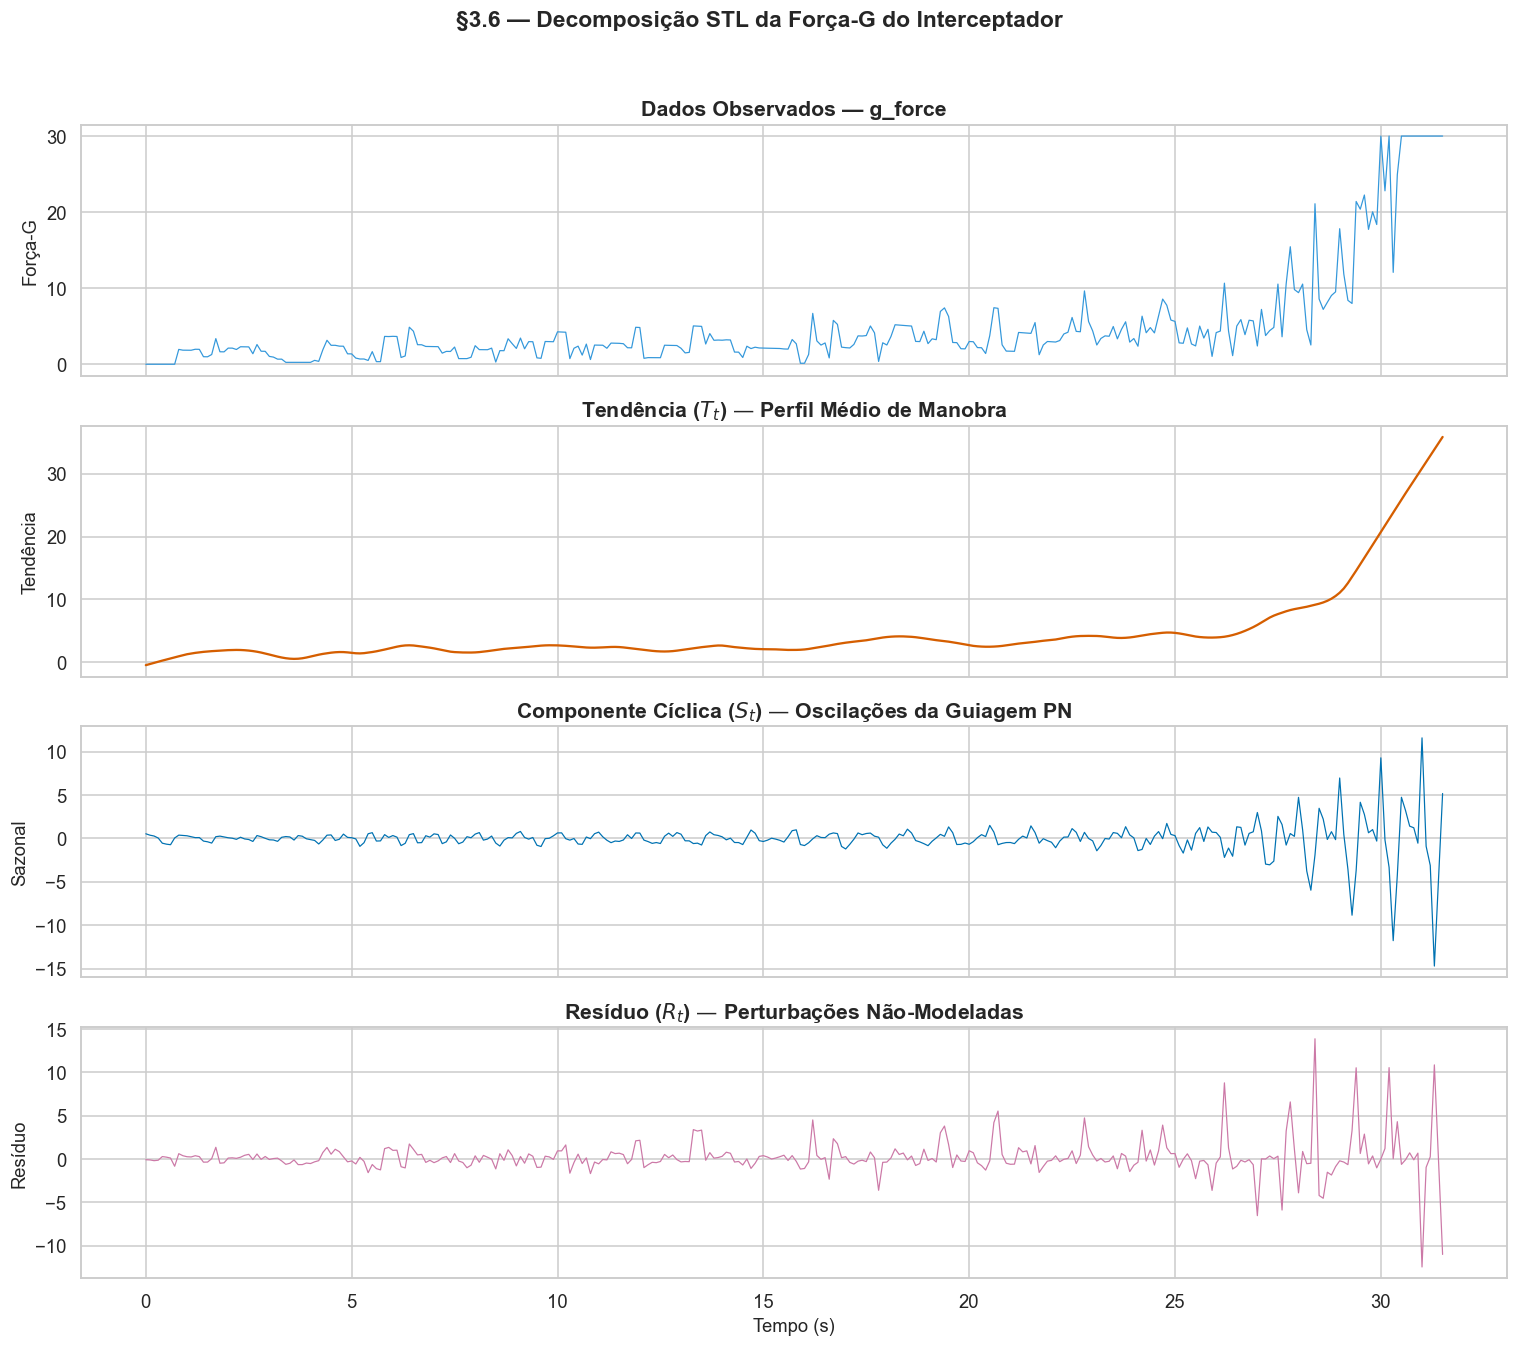

Força da Tendência (F_T):     0.8950
Força da Sazonalidade (F_S):  0.0000


In [18]:
gforce_ts = pd.Series(gforce, index=pd.RangeIndex(len(gforce)), name='G-Force')

stl_gforce = STL(gforce_ts, period=period, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(time, gforce, color=COLORS['gforce'], linewidth=0.8)
axes[0].set_ylabel('Força-G')
axes[0].set_title('Dados Observados — g_force', fontweight='bold')

axes[1].plot(time, stl_gforce.trend, color=COLORS['ma'], linewidth=1.5)
axes[1].set_ylabel('Tendência')
axes[1].set_title('Tendência ($T_t$) — Perfil Médio de Manobra', fontweight='bold')

axes[2].plot(time, stl_gforce.seasonal, color=COLORS['seasonal'], linewidth=0.8)
axes[2].set_ylabel('Sazonal')
axes[2].set_title('Componente Cíclica ($S_t$) — Oscilações da Guiagem PN', fontweight='bold')

axes[3].plot(time, stl_gforce.resid, color=COLORS['remainder'], linewidth=0.8)
axes[3].set_ylabel('Resíduo')
axes[3].set_xlabel('Tempo (s)')
axes[3].set_title('Resíduo ($R_t$) — Perturbações Não-Modeladas', fontweight='bold')

plt.suptitle('§3.6 — Decomposição STL da Força-G do Interceptador', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Força dos componentes
var_r_g = np.var(stl_gforce.resid)
var_sa_g = np.var(stl_gforce.resid + stl_gforce.trend)
var_dt_g = np.var(stl_gforce.resid + stl_gforce.seasonal)
F_trend_g = max(0, 1 - var_r_g / var_sa_g)
F_seasonal_g = max(0, 1 - var_r_g / var_dt_g)

print(f"Força da Tendência (F_T):     {F_trend_g:.4f}")
print(f"Força da Sazonalidade (F_S):  {F_seasonal_g:.4f}")

### 3.6.4 — Comparação: Decomposição Clássica vs STL

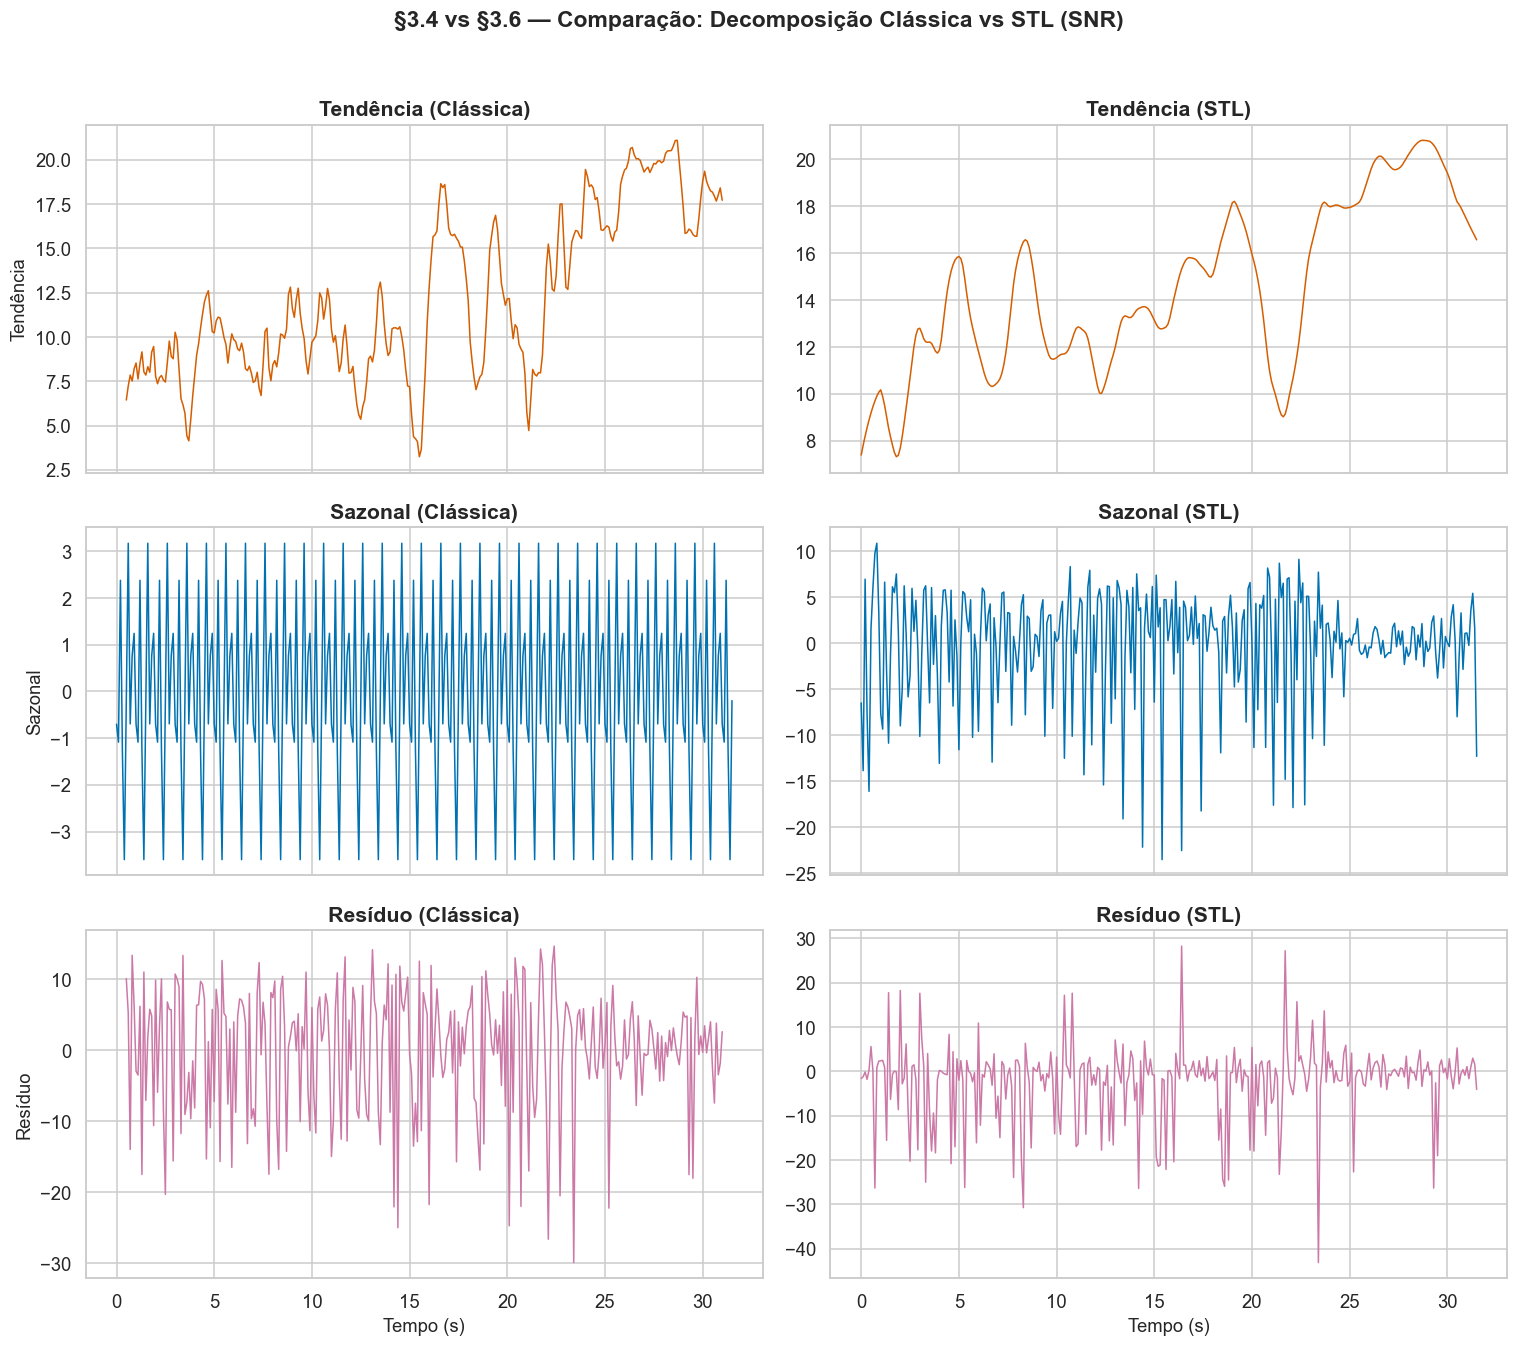

Métrica                                 Clássica          STL
--------------------------------------------------------------
Var(Resíduo):                            76.1517      75.8235
Observações sem tendência (bordas):           10            0
Robusto a outliers:                          Não          Sim
Sazonalidade variável:                       Não          Sim


In [19]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)

titles_left = ['Tendência (Clássica)', 'Sazonal (Clássica)', 'Resíduo (Clássica)']
titles_right = ['Tendência (STL)', 'Sazonal (STL)', 'Resíduo (STL)']
comps_classical = [decomp_classical.trend, decomp_classical.seasonal, decomp_classical.resid]
comps_stl = [stl_result.trend, stl_result.seasonal, stl_result.resid]
comp_colors = [COLORS['ma'], COLORS['seasonal'], COLORS['remainder']]

for i in range(3):
    # Clássica (esquerda)
    axes[i, 0].plot(time, comps_classical[i], color=comp_colors[i], linewidth=1)
    axes[i, 0].set_ylabel(titles_left[i].split(' (')[0])
    axes[i, 0].set_title(titles_left[i], fontweight='bold')
    
    # STL (direita)
    axes[i, 1].plot(time, comps_stl[i], color=comp_colors[i], linewidth=1)
    axes[i, 1].set_title(titles_right[i], fontweight='bold')

axes[2, 0].set_xlabel('Tempo (s)')
axes[2, 1].set_xlabel('Tempo (s)')

plt.suptitle('§3.4 vs §3.6 — Comparação: Decomposição Clássica vs STL (SNR)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tabela comparativa
cl_resid_var = np.nanvar(decomp_classical.resid)
stl_resid_var = np.var(stl_result.resid)
cl_nan_count = np.isnan(decomp_classical.trend).sum()

print(f"{'Métrica':<35} {'Clássica':>12} {'STL':>12}")
print("-" * 62)
print(f"{'Var(Resíduo):':<35} {cl_resid_var:>12.4f} {stl_resid_var:>12.4f}")
print(f"{'Observações sem tendência (bordas):':<35} {cl_nan_count:>12} {0:>12}")
print(f"{'Robusto a outliers:':<35} {'Não':>12} {'Sim':>12}")
print(f"{'Sazonalidade variável:':<35} {'Não':>12} {'Sim':>12}")

---
## Resumo e Conclusões

### O que aprendemos neste capítulo:

| Seção | Conceito | Aplicação Radar |
|-------|----------|------------------|
| §3.1 | **Transformações Box-Cox** | Estabilização da variância do RCS Swerling |
| §3.2 | **Componentes T + S + R** | Cinemática + Oscilações guiagem + Ruído |
| §3.3 | **Médias Móveis** | Filtragem passa-baixas de sinais radar |
| §3.4 | **Decomposição Clássica** | Separação tendência/resíduo (limitações nas bordas) |
| §3.6 | **Decomposição STL** | Decomposição robusta com tendência adaptativa |

### Insights Principais:

1. **Transformação Box-Cox** com $\lambda$ ótimo estabiliza a cintilação Swerling do RCS, tornando o sinal mais adequado para modelagem
2. **Médias Móveis** de diferentes ordens funcionam como filtros passa-baixas com largura de banda variável — crucial para processamento radar
3. **STL supera a decomposição clássica** para dados radar, pois:
   - Produz estimativas de tendência nas bordas
   - É robusto a outliers (picos de RCS)
   - Permite que a "sazonalidade" (oscilações da guiagem) evolua
4. A **variância do resíduo** é consistentemente menor no STL, indicando extração mais eficiente dos componentes determinísticos

### Próximo Capítulo:
- **Capítulo 4 — Features de Séries Temporais**: Extração de métricas quantitativas (autocorrelação, força de tendência/sazonalidade, etc.)

---
*Notebook desenvolvido como parte do estudo de séries temporais aplicadas a sistemas radar, utilizando dados do simulador [Glaukopis](https://github.com/rafaelwilliamm/glaukopis).*